### Finding the focal plane to locate the camera

The SLM's pixels are a bit shitty on the edges. So I will try to locate where it starts becoming bad.

In order to do this, I will use variable sizes at the center of the SLM to form the airy disk at the camera and then see at what size of the patch does the airy disk start becoming bad. That will tell us how the SLM's pixels are behaving radially.


Found images:
 1.0 mm : 1mm.tiff
 1.5 mm : 1.5mm.tiff
 2.0 mm : 2mm.tiff
 2.5 mm : 2.5mm.tiff
 3.0 mm : 3mm.tiff
 3.5 mm : 3.5mm.tiff
 4.0 mm : 4mm.tiff
 4.5 mm : 4.5mm.tiff
 5.0 mm : 5mm.tiff
 5.5 mm : 5.5mm.tiff
 6.0 mm : 6mm.tiff
 6.5 mm : 6.5mm.tiff
 7.0 mm : 7mm.tiff
 7.5 mm : 7.5mm.tiff
 8.0 mm : 8mm.tiff
 8.5 mm : 8.5mm.tiff
 9.0 mm : 9mm.tiff
 9.5 mm : 9.5mm.tiff
 9.6 mm : 9.6mm.tiff

Analysing 1.0 mm ...

Analysing 1.5 mm ...

Analysing 2.0 mm ...

Analysing 2.5 mm ...

Analysing 3.0 mm ...

Analysing 3.5 mm ...

Analysing 4.0 mm ...

Analysing 4.5 mm ...

Analysing 5.0 mm ...

Analysing 5.5 mm ...

Analysing 6.0 mm ...

Analysing 6.5 mm ...

Analysing 7.0 mm ...

Analysing 7.5 mm ...

Analysing 8.0 mm ...

Analysing 8.5 mm ...

Analysing 9.0 mm ...

Analysing 9.5 mm ...

Analysing 9.6 mm ...

RESULTS
 patch_mm  theory_fwhm_um  fwhm_x_um  fwhm_y_um  scale_x  scale_y  ellipticity   R2_x   R2_y  saturated
   1.0000        195.5162   202.0231   195.4111   1.0333   0.9995       1

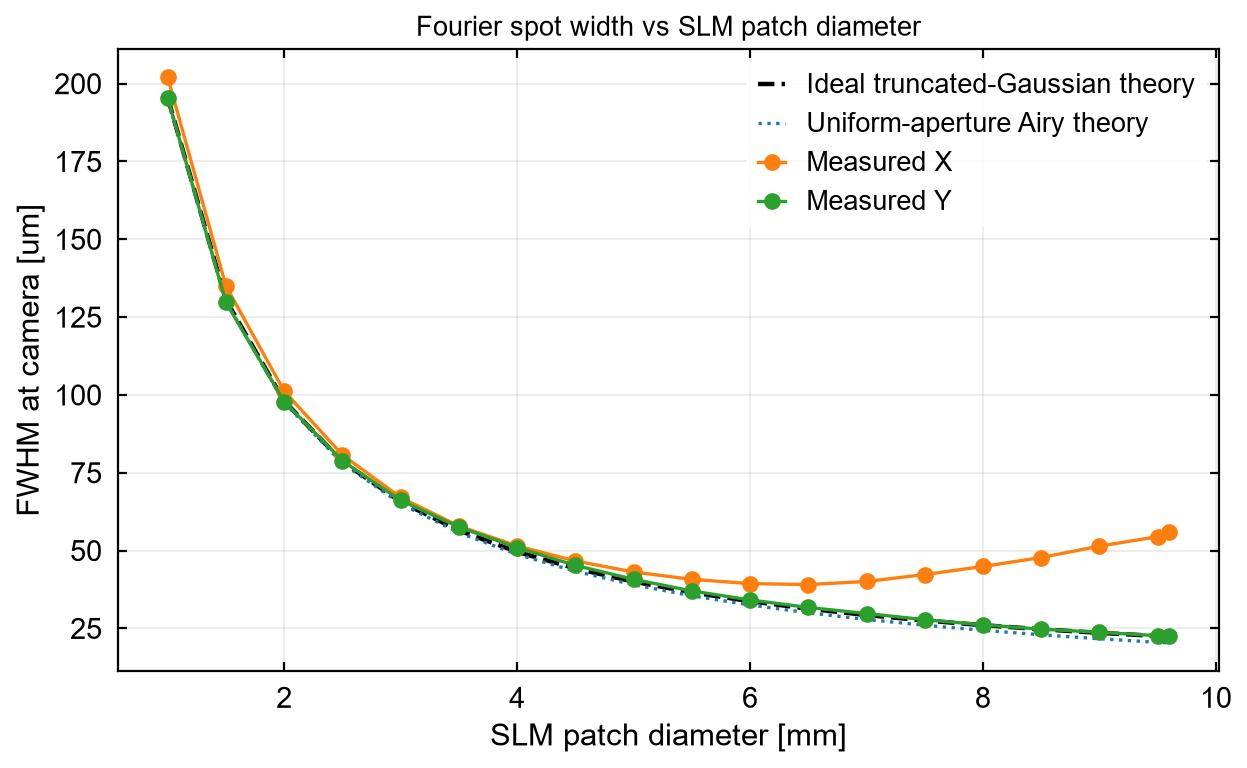

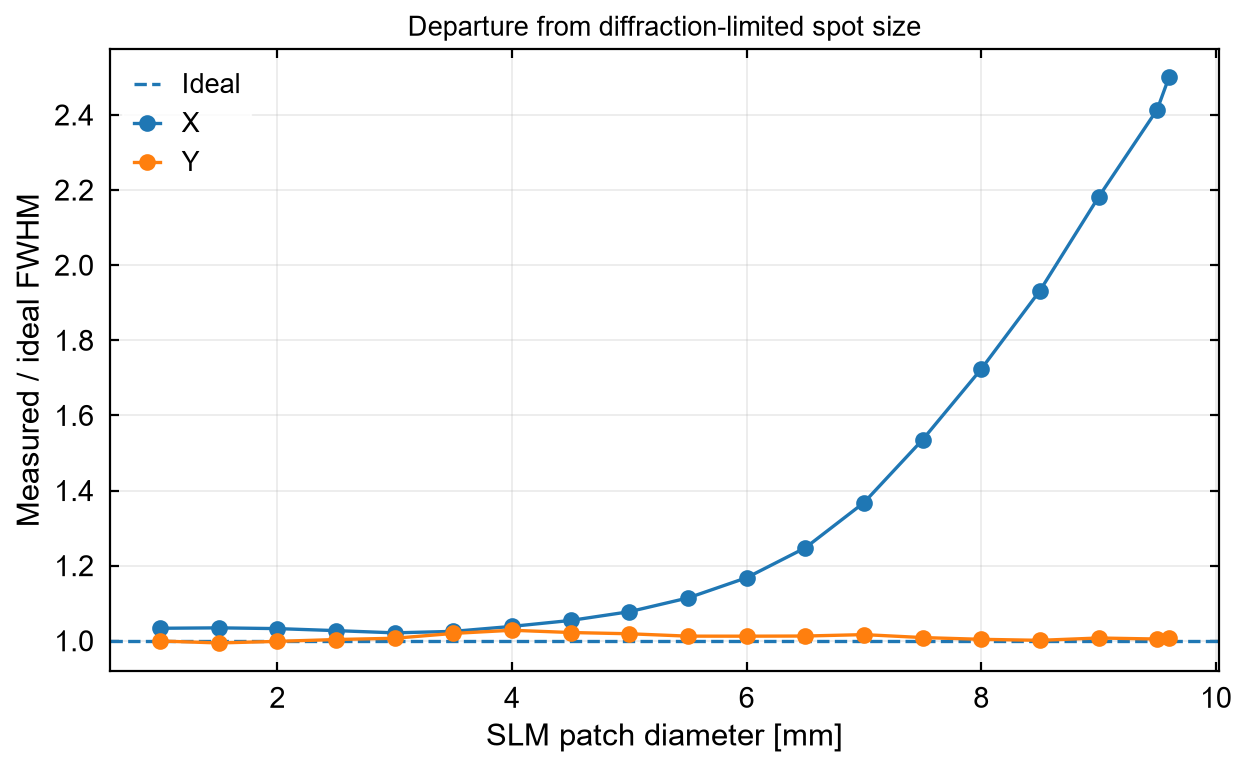

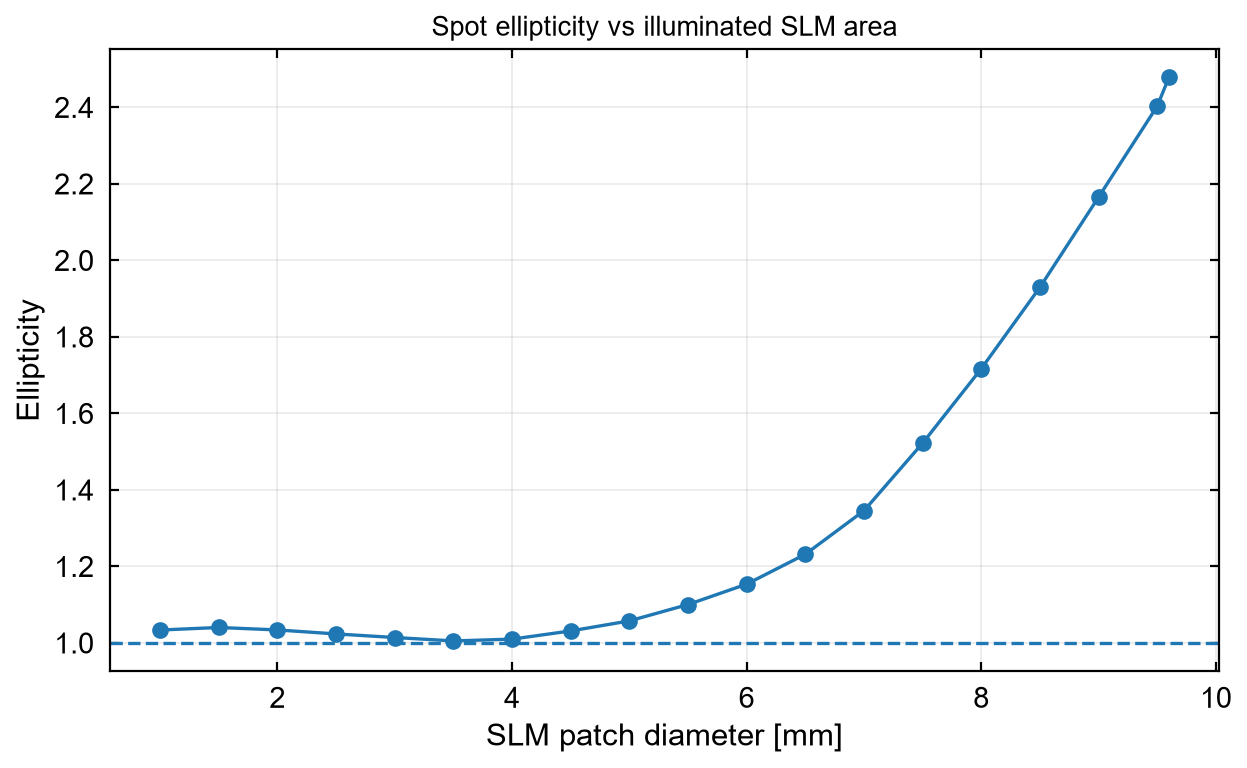

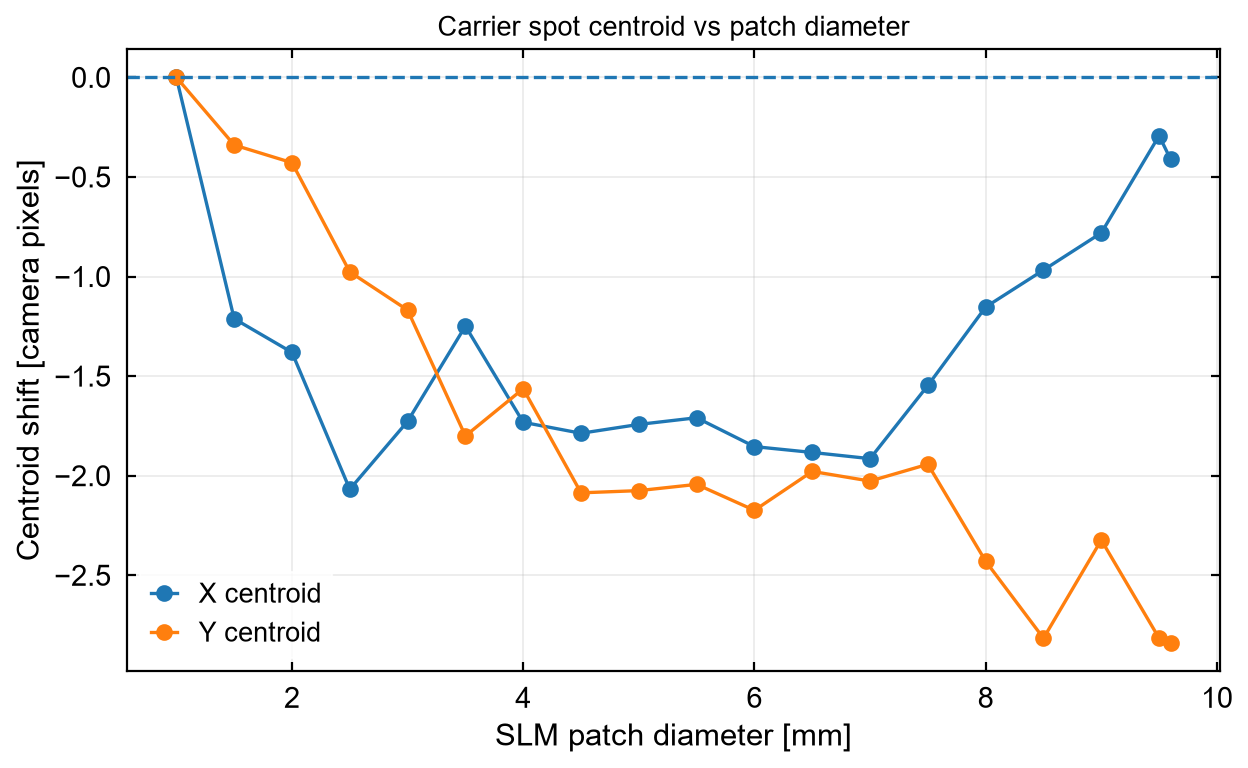

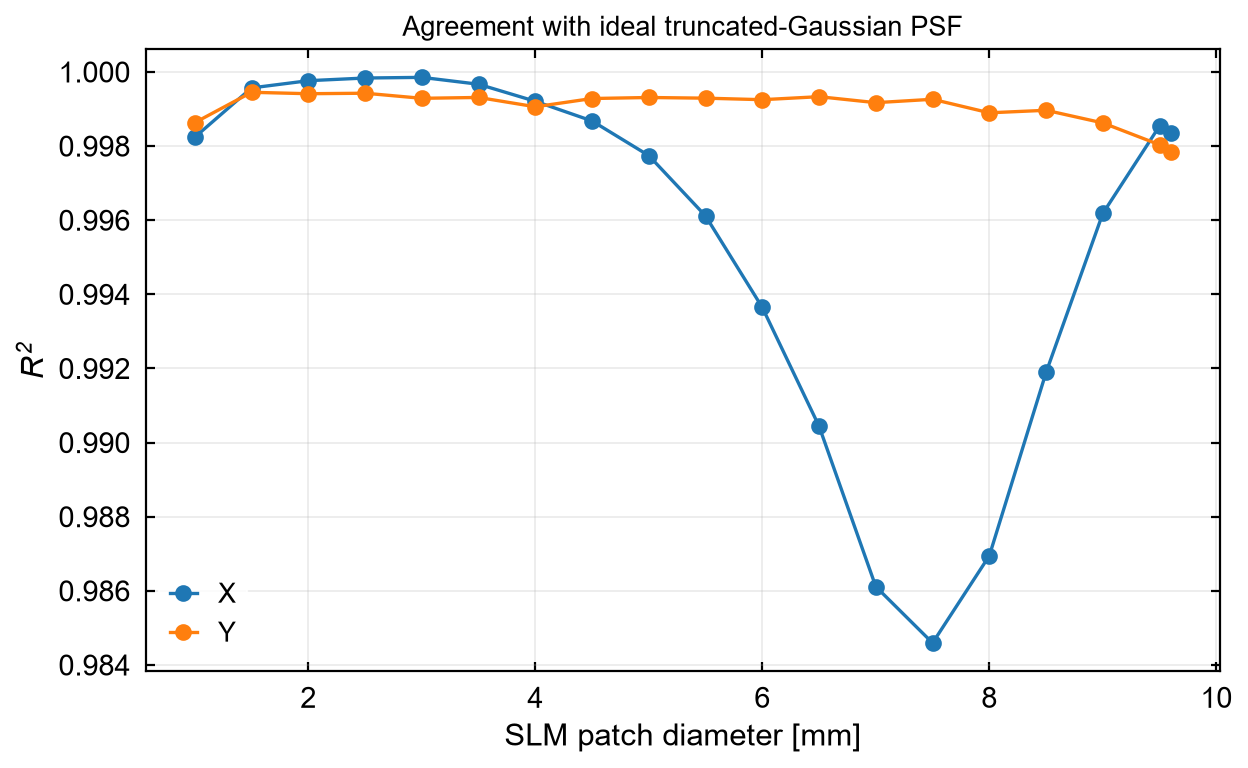

In [3]:
# ============================================================
# Batch analysis of SLM diagnostic carrier spots
#
# Assumptions:
#   wavelength = 759.3 nm
#   L1 focal length = 250 mm
#   camera pixel = 2.4 um
#   incident beam 1/e^2 diameter = 9.6 mm
#
# Expected filenames:
#   1mm.bmp
#   1.5mm.bmp
#   2mm.bmp
#   ...
#   9.5mm.bmp
#   9.6mm.bmp
#
# Laser power may change between images:
# absolute brightness is NOT compared.
# ============================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)


from PIL import Image

from scipy.optimize import curve_fit
from scipy.special import j0


# ============================================================
# USER SETTINGS
# ============================================================

FOLDER = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\Alignment\02Sept"
)

WAVELENGTH_NM = 759.3
FOCAL_LENGTH_MM = 250.0

CAMERA_PIXEL_UM = 2.4

# Input Gaussian beam on SLM
# This is the measured 1/e^2 INTENSITY diameter
BEAM_DIAMETER_MM = 9.6
BEAM_RADIUS_MM = BEAM_DIAMETER_MM / 2

# Average this many camera pixels transverse to each linecut
PROFILE_AVERAGE_WIDTH = 5

# Allowed fit broadening relative to ideal diffraction
MIN_SCALE = 0.3
MAX_SCALE = 5.0

# Valid image formats
IMAGE_EXTENSIONS = {
    ".bmp", ".png", ".jpg", ".jpeg", ".tif", ".tiff"
}


# ============================================================
# PHYSICAL CONSTANTS
# ============================================================

lambda_m = WAVELENGTH_NM * 1e-9
f_m = FOCAL_LENGTH_MM * 1e-3
pixel_m = CAMERA_PIXEL_UM * 1e-6

w_slm_m = BEAM_RADIUS_MM * 1e-3


# ============================================================
# GET PATCH DIAMETER FROM FILENAME
# ============================================================

def get_patch_diameter(filename):
    """
    Extracts diameter from filenames such as:

        1mm.bmp
        1.5mm.bmp
        9.6mm.bmp
    """

    match = re.search(
        r"([0-9]+(?:\.[0-9]+)?)\s*mm",
        filename.lower()
    )

    if match is None:
        return None

    return float(match.group(1))


# ============================================================
# LOAD IMAGE
# ============================================================

def load_image(path):

    raw = np.array(Image.open(path))

    original_dtype = raw.dtype

    # Convert RGB -> grayscale if necessary
    if raw.ndim == 3:
        raw = raw.astype(float).mean(axis=2)
    else:
        raw = raw.astype(float)

    # Possible digital saturation level
    if np.issubdtype(original_dtype, np.integer):
        max_possible = np.iinfo(original_dtype).max
    else:
        max_possible = np.nan

    return raw, max_possible


# ============================================================
# ROBUST BACKGROUND ESTIMATE
# ============================================================

def estimate_background(img):

    # Use low percentile rather than image border,
    # because the 1-mm spot may be very broad.
    return np.percentile(img, 5)


# ============================================================
# LOCATE SPOT
# ============================================================

def find_spot_center(img, background):

    signal = img - background
    signal[signal < 0] = 0

    # Find brightest pixel first
    y_peak, x_peak = np.unravel_index(
        np.argmax(signal),
        signal.shape
    )

    # Refine centroid using pixels above 10% of maximum.
    threshold = 0.10 * signal.max()

    weights = np.where(
        signal >= threshold,
        signal,
        0
    )

    yy, xx = np.indices(signal.shape)

    total = weights.sum()

    if total <= 0:
        return float(x_peak), float(y_peak)

    x_com = np.sum(xx * weights) / total
    y_com = np.sum(yy * weights) / total

    return x_com, y_com


# ============================================================
# TRUNCATED-GAUSSIAN FOURIER PSF
# ============================================================

def calculate_ideal_psf(
    patch_diameter_mm,
    rho_max_um,
    n_rho=2500,
    n_slm=2000
):
    """
    Calculates Fraunhofer intensity of

        E(r) = exp(-r^2 / w^2)

    truncated by circular aperture

        r <= D/2.

    Here w is the 1/e^2 INTENSITY radius of the input beam,
    since intensity is:

        I(r) = exp(-2 r^2 / w^2)

    The returned PSF is normalized to 1 at rho = 0.
    """

    R_m = patch_diameter_mm * 1e-3 / 2

    # SLM radial coordinate
    r = np.linspace(0, R_m, n_slm)

    # Gaussian FIELD amplitude
    amplitude_slm = np.exp(
        -(r / w_slm_m)**2
    )

    rho_um = np.linspace(
        0,
        rho_max_um,
        n_rho
    )

    rho_m = rho_um * 1e-6

    # Fraunhofer/Hankel transform:
    #
    # E(rho) ∝ integral r E(r) J0(qr) dr
    #
    # q = 2π rho / (lambda f)

    q = (
        2 * np.pi * rho_m /
        (lambda_m * f_m)
    )

    # Matrix dimensions:
    # n_rho x n_slm

    qr = q[:, None] * r[None, :]

    integrand = (
        amplitude_slm[None, :]
        * j0(qr)
        * r[None, :]
    )

    field = np.trapezoid(
        integrand,
        r,
        axis=1
    )

    intensity = np.abs(field)**2

    intensity /= intensity[0]

    return rho_um, intensity


# ============================================================
# FIND THEORETICAL FWHM
# ============================================================

def find_fwhm_from_radial_psf(rho_um, intensity):

    # Find first crossing below half maximum
    below = np.where(intensity <= 0.5)[0]

    if len(below) == 0:
        return np.nan

    i = below[0]

    if i == 0:
        return np.nan

    # Linear interpolation
    x1 = rho_um[i - 1]
    x2 = rho_um[i]

    y1 = intensity[i - 1]
    y2 = intensity[i]

    r_half = x1 + (
        (0.5 - y1)
        * (x2 - x1)
        / (y2 - y1)
    )

    # Full width
    return 2 * r_half


# ============================================================
# PROFILE MODEL
# ============================================================

def make_profile_model(rho_um, ideal_intensity):

    def model(pixel_coordinate, amplitude, center, scale, background):

        distance_um = (
            np.abs(pixel_coordinate - center)
            * CAMERA_PIXEL_UM
        )

        # scale > 1 -> measured spot broader than ideal
        ideal_coordinate = distance_um / scale

        psf = np.interp(
            ideal_coordinate,
            rho_um,
            ideal_intensity,
            left=1.0,
            right=0.0
        )

        return background + amplitude * psf

    return model


# ============================================================
# GOODNESS OF FIT
# ============================================================

def calculate_r2(data, fit):

    ss_res = np.sum((data - fit)**2)
    ss_tot = np.sum(
        (data - np.mean(data))**2
    )

    if ss_tot == 0:
        return np.nan

    return 1 - ss_res / ss_tot


# ============================================================
# ANALYSE ONE IMAGE
# ============================================================

def analyse_image(path, patch_diameter_mm, plot=False):

    img, max_possible = load_image(path)

    ny, nx = img.shape

    background = estimate_background(img)

    x_center, y_center = find_spot_center(
        img,
        background
    )

    xc = int(round(x_center))
    yc = int(round(y_center))

    half = PROFILE_AVERAGE_WIDTH // 2

    # --------------------------------------------------------
    # X profile
    # --------------------------------------------------------

    y1 = max(0, yc - half)
    y2 = min(ny, yc + half + 1)

    x_profile = np.mean(
        img[y1:y2, :],
        axis=0
    )

    # --------------------------------------------------------
    # Y profile
    # --------------------------------------------------------

    x1 = max(0, xc - half)
    x2 = min(nx, xc + half + 1)

    y_profile = np.mean(
        img[:, x1:x2],
        axis=1
    )

    x_pixels = np.arange(nx)
    y_pixels = np.arange(ny)

    # --------------------------------------------------------
    # Calculate ideal truncated-Gaussian PSF
    # --------------------------------------------------------

    max_radius_um = (
        max(nx, ny)
        * CAMERA_PIXEL_UM
        * 1.5
    )

    rho_um, ideal_psf = calculate_ideal_psf(
        patch_diameter_mm,
        max_radius_um
    )

    theoretical_fwhm_um = (
        find_fwhm_from_radial_psf(
            rho_um,
            ideal_psf
        )
    )

    theoretical_fwhm_px = (
        theoretical_fwhm_um
        / CAMERA_PIXEL_UM
    )

    model = make_profile_model(
        rho_um,
        ideal_psf
    )

    # --------------------------------------------------------
    # Fit X
    # --------------------------------------------------------

    p0_x = [
        x_profile.max() - background,
        x_center,
        1.0,
        background
    ]

    bounds_x = (
        [
            0,
            max(0, x_center - 20),
            MIN_SCALE,
            -np.inf
        ],
        [
            np.inf,
            min(nx - 1, x_center + 20),
            MAX_SCALE,
            np.inf
        ]
    )

    popt_x, pcov_x = curve_fit(
        model,
        x_pixels,
        x_profile,
        p0=p0_x,
        bounds=bounds_x,
        maxfev=50000
    )

    amp_x, x0_fit, scale_x, bg_x = popt_x

    x_fit = model(
        x_pixels,
        *popt_x
    )

    # --------------------------------------------------------
    # Fit Y
    # --------------------------------------------------------

    p0_y = [
        y_profile.max() - background,
        y_center,
        1.0,
        background
    ]

    bounds_y = (
        [
            0,
            max(0, y_center - 20),
            MIN_SCALE,
            -np.inf
        ],
        [
            np.inf,
            min(ny - 1, y_center + 20),
            MAX_SCALE,
            np.inf
        ]
    )

    popt_y, pcov_y = curve_fit(
        model,
        y_pixels,
        y_profile,
        p0=p0_y,
        bounds=bounds_y,
        maxfev=50000
    )

    amp_y, y0_fit, scale_y, bg_y = popt_y

    y_fit = model(
        y_pixels,
        *popt_y
    )

    # --------------------------------------------------------
    # FWHM
    # --------------------------------------------------------

    fwhm_x_um = (
        scale_x * theoretical_fwhm_um
    )

    fwhm_y_um = (
        scale_y * theoretical_fwhm_um
    )

    fwhm_x_px = (
        fwhm_x_um / CAMERA_PIXEL_UM
    )

    fwhm_y_px = (
        fwhm_y_um / CAMERA_PIXEL_UM
    )

    # --------------------------------------------------------
    # Ellipticity
    # --------------------------------------------------------

    ellipticity = (
        max(fwhm_x_um, fwhm_y_um)
        /
        min(fwhm_x_um, fwhm_y_um)
    )

    # --------------------------------------------------------
    # Fit quality
    # --------------------------------------------------------

    r2_x = calculate_r2(
        x_profile,
        x_fit
    )

    r2_y = calculate_r2(
        y_profile,
        y_fit
    )

    # --------------------------------------------------------
    # Saturation check
    # --------------------------------------------------------

    peak = img.max()

    if np.isfinite(max_possible):
        saturated = (
            peak >= 0.98 * max_possible
        )
    else:
        saturated = False

    # --------------------------------------------------------
    # Pure Airy prediction for reference
    # --------------------------------------------------------

    D_m = patch_diameter_mm * 1e-3

    airy_fwhm_um = (
        1.028
        * lambda_m
        * f_m
        / D_m
        * 1e6
    )

    # --------------------------------------------------------
    # Optional plot for this image
    # --------------------------------------------------------

    if plot:

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(16, 4.5)
        )

        # Image
        axes[0].imshow(
            img,
            origin="upper",
            cmap="inferno"
        )

        axes[0].axvline(
            x0_fit,
            linestyle="--"
        )

        axes[0].axhline(
            y0_fit,
            linestyle="--"
        )

        axes[0].set_title(
            f"{patch_diameter_mm:.1f} mm patch"
        )

        axes[0].set_xlabel("x [pixel]")
        axes[0].set_ylabel("y [pixel]")

        # X
        axes[1].plot(
            x_pixels,
            x_profile,
            ".",
            label="Data"
        )

        axes[1].plot(
            x_pixels,
            x_fit,
            "-",
            label="Fit"
        )

        axes[1].set_title(
            f"X: FWHM = {fwhm_x_um:.1f} um\n"
            f"scale = {scale_x:.3f}, "
            f"$R^2$ = {r2_x:.4f}"
        )

        axes[1].set_xlabel("x [pixel]")
        axes[1].set_ylabel("Counts")
        axes[1].legend()

        # Y
        axes[2].plot(
            y_pixels,
            y_profile,
            ".",
            label="Data"
        )

        axes[2].plot(
            y_pixels,
            y_fit,
            "-",
            label="Fit"
        )

        axes[2].set_title(
            f"Y: FWHM = {fwhm_y_um:.1f} um\n"
            f"scale = {scale_y:.3f}, "
            f"$R^2$ = {r2_y:.4f}"
        )

        axes[2].set_xlabel("y [pixel]")
        axes[2].set_ylabel("Counts")
        axes[2].legend()

        fig.suptitle(
            f"{path.name}"
        )

        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # Return results
    # --------------------------------------------------------

    return {
        "filename": path.name,

        "patch_mm": patch_diameter_mm,

        "x_center_px": x0_fit,
        "y_center_px": y0_fit,

        "theory_fwhm_um":
            theoretical_fwhm_um,

        "airy_fwhm_um":
            airy_fwhm_um,

        "fwhm_x_um":
            fwhm_x_um,

        "fwhm_y_um":
            fwhm_y_um,

        "fwhm_x_px":
            fwhm_x_px,

        "fwhm_y_px":
            fwhm_y_px,

        # The most useful diffraction-quality metric:
        # ideal = 1
        "scale_x":
            scale_x,

        "scale_y":
            scale_y,

        "ellipticity":
            ellipticity,

        "R2_x":
            r2_x,

        "R2_y":
            r2_y,

        # Brightness retained ONLY as diagnostic;
        # do not compare between files if laser power changed.
        "peak_counts":
            peak,

        "saturated":
            saturated
    }


# ============================================================
# FIND ALL IMAGES
# ============================================================

files = []

for path in FOLDER.iterdir():

    if path.suffix.lower() not in IMAGE_EXTENSIONS:
        continue

    diameter = get_patch_diameter(
        path.name
    )

    if diameter is None:
        print(
            "Skipping: could not determine patch size:",
            path.name
        )
        continue

    files.append(
        (diameter, path)
    )


files.sort(
    key=lambda item: item[0]
)

print()
print("Found images:")
for diameter, path in files:
    print(
        f"{diameter:4.1f} mm : {path.name}"
    )


# ============================================================
# RUN BATCH ANALYSIS
# ============================================================

results = []

for diameter, path in files:

    print()
    print(
        f"Analysing {diameter:.1f} mm ..."
    )

    try:

        result = analyse_image(
            path,
            diameter,
            plot=False
        )

        results.append(
            result
        )

    except Exception as exc:

        print(
            "FIT FAILED:",
            path.name,
            exc
        )


df = pd.DataFrame(results)

df = df.sort_values(
    "patch_mm"
).reset_index(drop=True)


# ============================================================
# PRINT TABLE
# ============================================================

columns_to_show = [
    "patch_mm",
    "theory_fwhm_um",
    "fwhm_x_um",
    "fwhm_y_um",
    "scale_x",
    "scale_y",
    "ellipticity",
    "R2_x",
    "R2_y",
    "saturated"
]

print()
print("=" * 100)
print("RESULTS")
print("=" * 100)

print(
    df[columns_to_show].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# SAVE CSV
# ============================================================

csv_path = (
    FOLDER
    / "SLM_patch_analysis.csv"
)

df.to_csv(
    csv_path,
    index=False
)

print()
print(
    "Saved results to:"
)
print(csv_path)


# ============================================================
# TREND 1:
# FWHM versus patch diameter
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df["patch_mm"],
    df["theory_fwhm_um"],
    "k--",
    linewidth=2,
    label="Ideal truncated-Gaussian theory"
)

plt.plot(
    df["patch_mm"],
    df["airy_fwhm_um"],
    ":",
    linewidth=1.5,
    label="Uniform-aperture Airy theory"
)

plt.plot(
    df["patch_mm"],
    df["fwhm_x_um"],
    "o-",
    label="Measured X"
)

plt.plot(
    df["patch_mm"],
    df["fwhm_y_um"],
    "o-",
    label="Measured Y"
)

plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    "FWHM at camera [um]"
)

plt.title(
    "Fourier spot width vs SLM patch diameter"
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# TREND 2:
# Measured / diffraction-limited width
#
# Ideal value = 1
# ============================================================

plt.figure(figsize=(8, 5))

plt.axhline(
    1,
    linestyle="--",
    label="Ideal"
)

plt.plot(
    df["patch_mm"],
    df["scale_x"],
    "o-",
    label="X"
)

plt.plot(
    df["patch_mm"],
    df["scale_y"],
    "o-",
    label="Y"
)

plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    "Measured / ideal FWHM"
)

plt.title(
    "Departure from diffraction-limited spot size"
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# TREND 3:
# ELLIPTICITY
#
# Ideal value = 1
# ============================================================

plt.figure(figsize=(8, 5))

plt.axhline(
    1,
    linestyle="--"
)

plt.plot(
    df["patch_mm"],
    df["ellipticity"],
    "o-"
)

plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    "Ellipticity"
)

plt.title(
    "Spot ellipticity vs illuminated SLM area"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ============================================================
# TREND 4:
# X and Y centroid
#
# Useful for detecting beam/SLM alignment changes
# ============================================================

plt.figure(figsize=(8, 5))

x_reference = df["x_center_px"].iloc[0]
y_reference = df["y_center_px"].iloc[0]

plt.plot(
    df["patch_mm"],
    df["x_center_px"] - x_reference,
    "o-",
    label="X centroid"
)

plt.plot(
    df["patch_mm"],
    df["y_center_px"] - y_reference,
    "o-",
    label="Y centroid"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    "Centroid shift [camera pixels]"
)

plt.title(
    "Carrier spot centroid vs patch diameter"
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# TREND 5:
# FIT QUALITY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df["patch_mm"],
    df["R2_x"],
    "o-",
    label="X"
)

plt.plot(
    df["patch_mm"],
    df["R2_y"],
    "o-",
    label="Y"
)

plt.xlabel(
    "SLM patch diameter [mm]"
)

plt.ylabel(
    r"$R^2$"
)

plt.title(
    "Agreement with ideal truncated-Gaussian PSF"
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### z-scan of the camera for the above

now I will scan with a stage to see if there exists a minima for the spot

Found 35 images.
  0.00 : 0.tiff
  1.00 : 1.tiff
  2.00 : 2.tiff
  3.00 : 3.tiff
  4.00 : 4.tiff
  5.00 : 5.tiff
  6.00 : 6.tiff
  7.00 : 7.tiff
  8.00 : 8.tiff
  9.00 : 9.tiff
 10.00 : 10.tiff
 11.00 : 11.tiff
 12.00 : 12.tiff
 13.00 : 13.tiff
 14.00 : 14.tiff
 15.00 : 15.tiff
 16.00 : 16.tiff
 17.00 : 17.tiff
 18.00 : 18.tiff
 19.00 : 19.tiff
 20.00 : 20.tiff
 21.00 : 21.tiff
 22.00 : 22.tiff
 23.00 : 23.tiff
 24.00 : 24.tiff
 25.00 : 25.tiff
 26.00 : 26.tiff
 27.00 : 27.tiff
 28.00 : 28.tiff
 29.00 : 29.tiff
 30.00 : 30.tiff
 31.00 : 31.tiff
 32.00 : 32.tiff
 33.00 : 33.tiff
 34.00 : 34.tiff
Analysing 1/35 : 0.tiff
Analysing 2/35 : 1.tiff
Analysing 3/35 : 2.tiff
Analysing 4/35 : 3.tiff
Analysing 5/35 : 4.tiff
Analysing 6/35 : 5.tiff
Analysing 7/35 : 6.tiff
Analysing 8/35 : 7.tiff
Analysing 9/35 : 8.tiff
Analysing 10/35 : 9.tiff
Analysing 11/35 : 10.tiff
Analysing 12/35 : 11.tiff
Analysing 13/35 : 12.tiff
Analysing 14/35 : 13.tiff
Analysing 15/35 : 14.tiff
Analysing 16/35 : 15.tiff
A

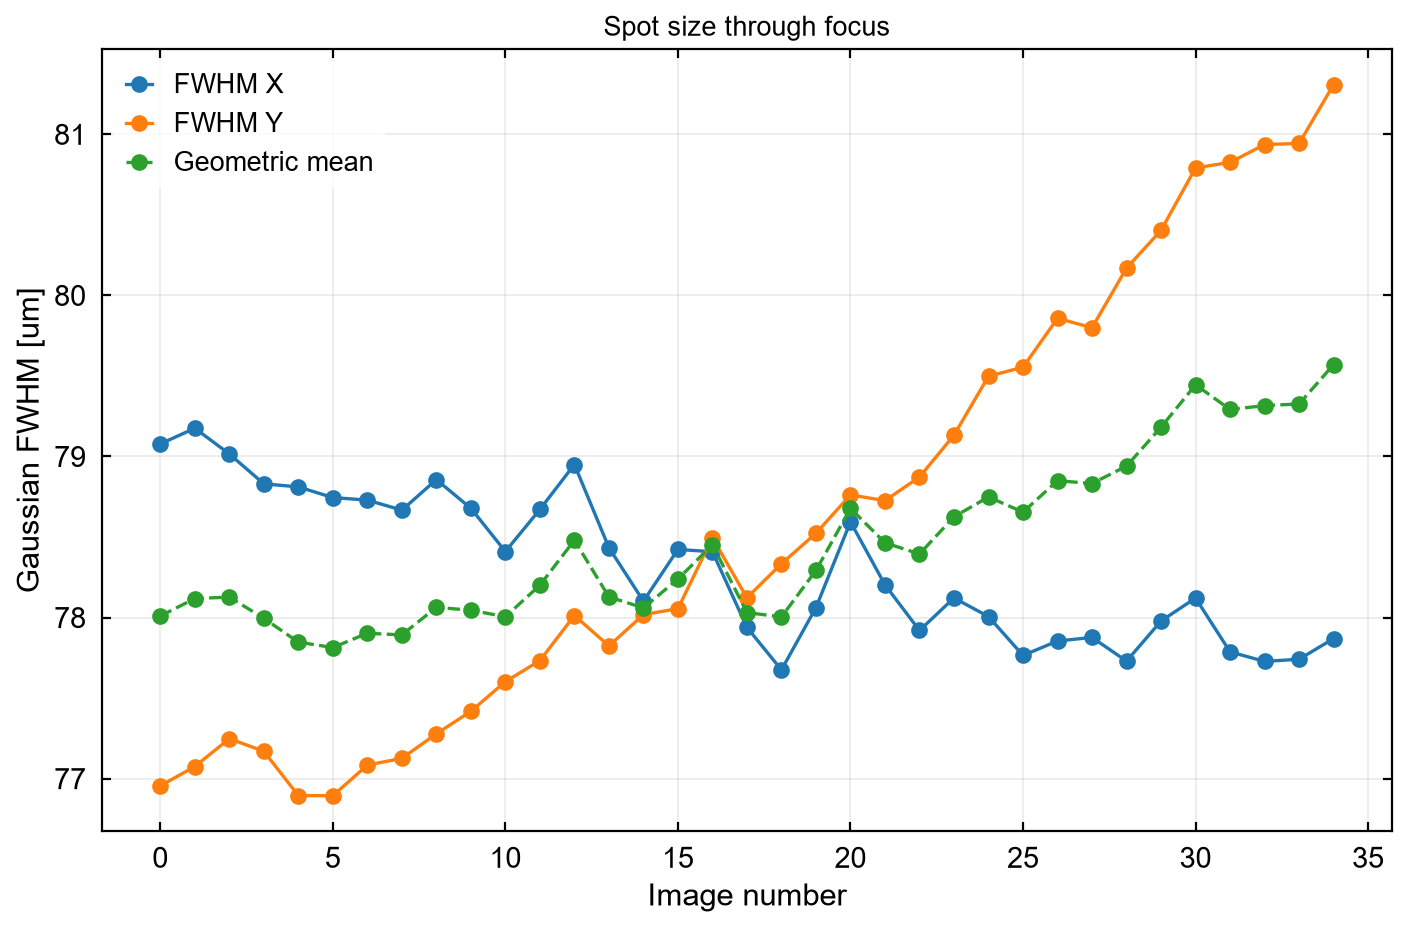

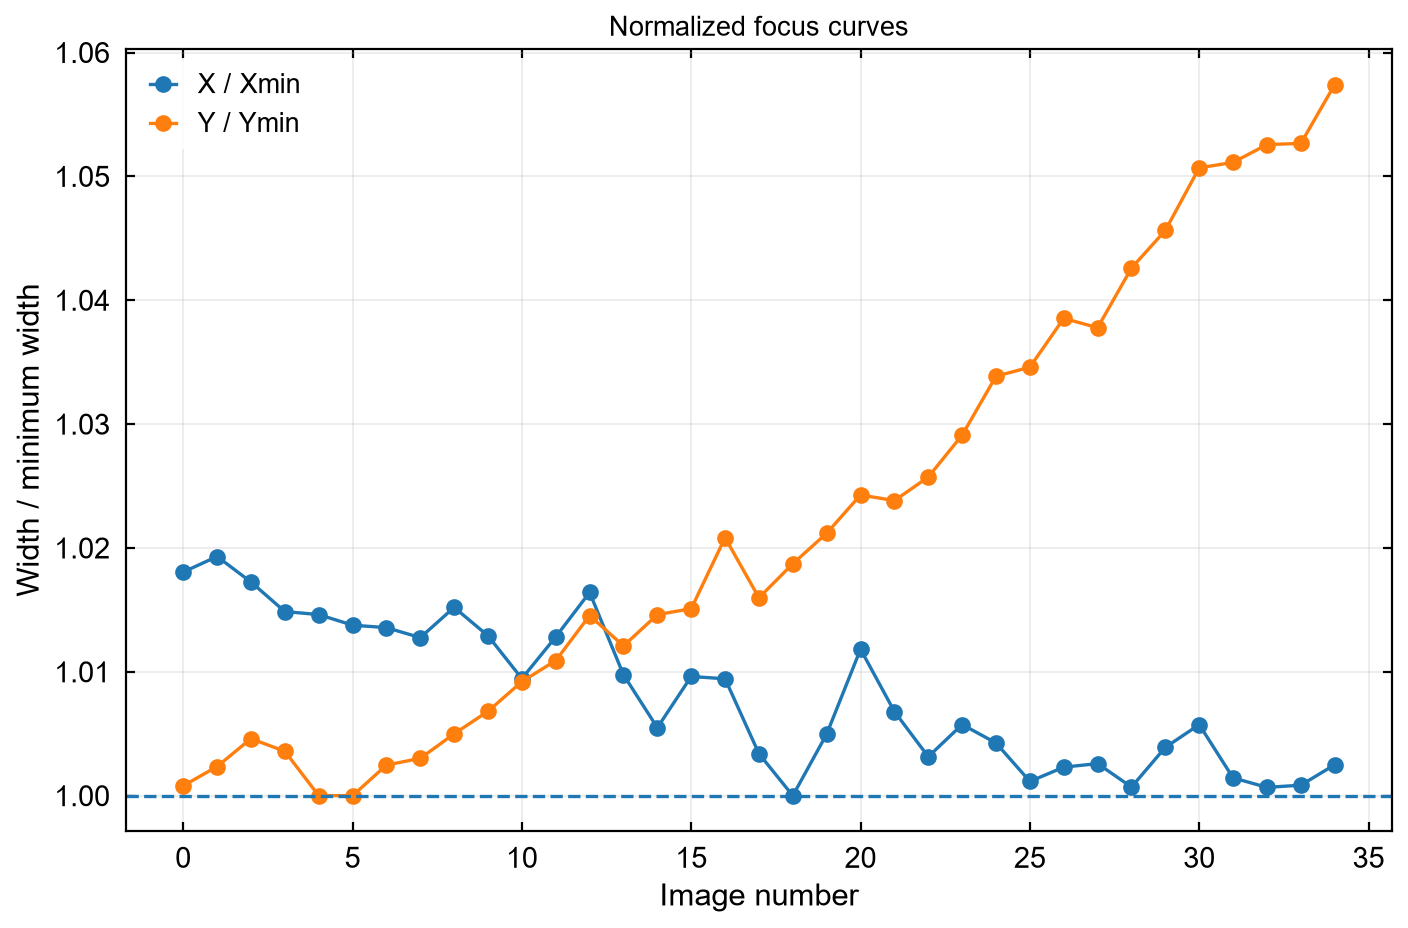

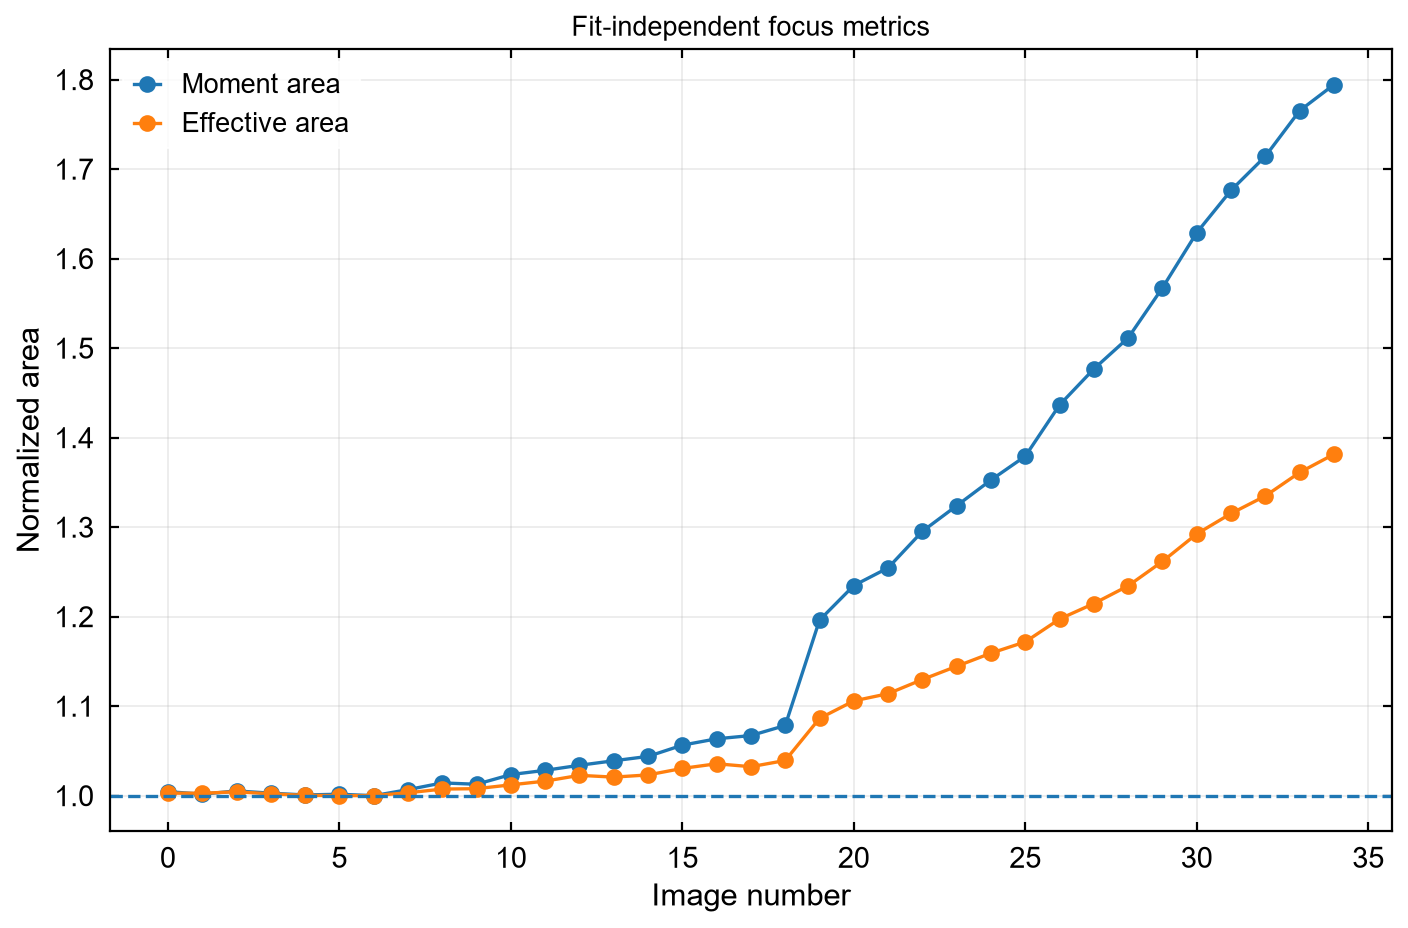

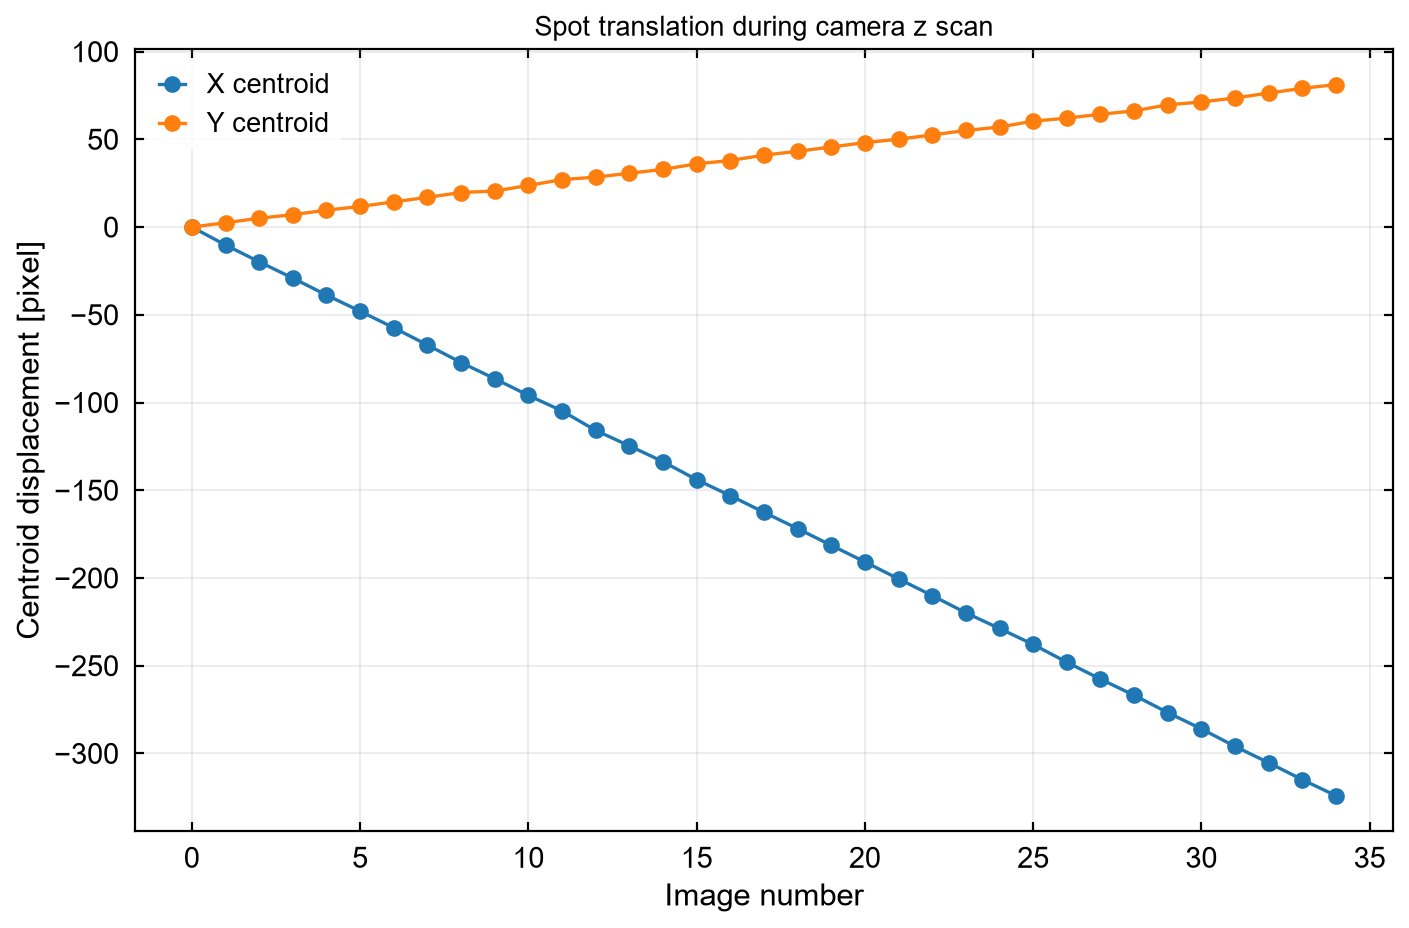

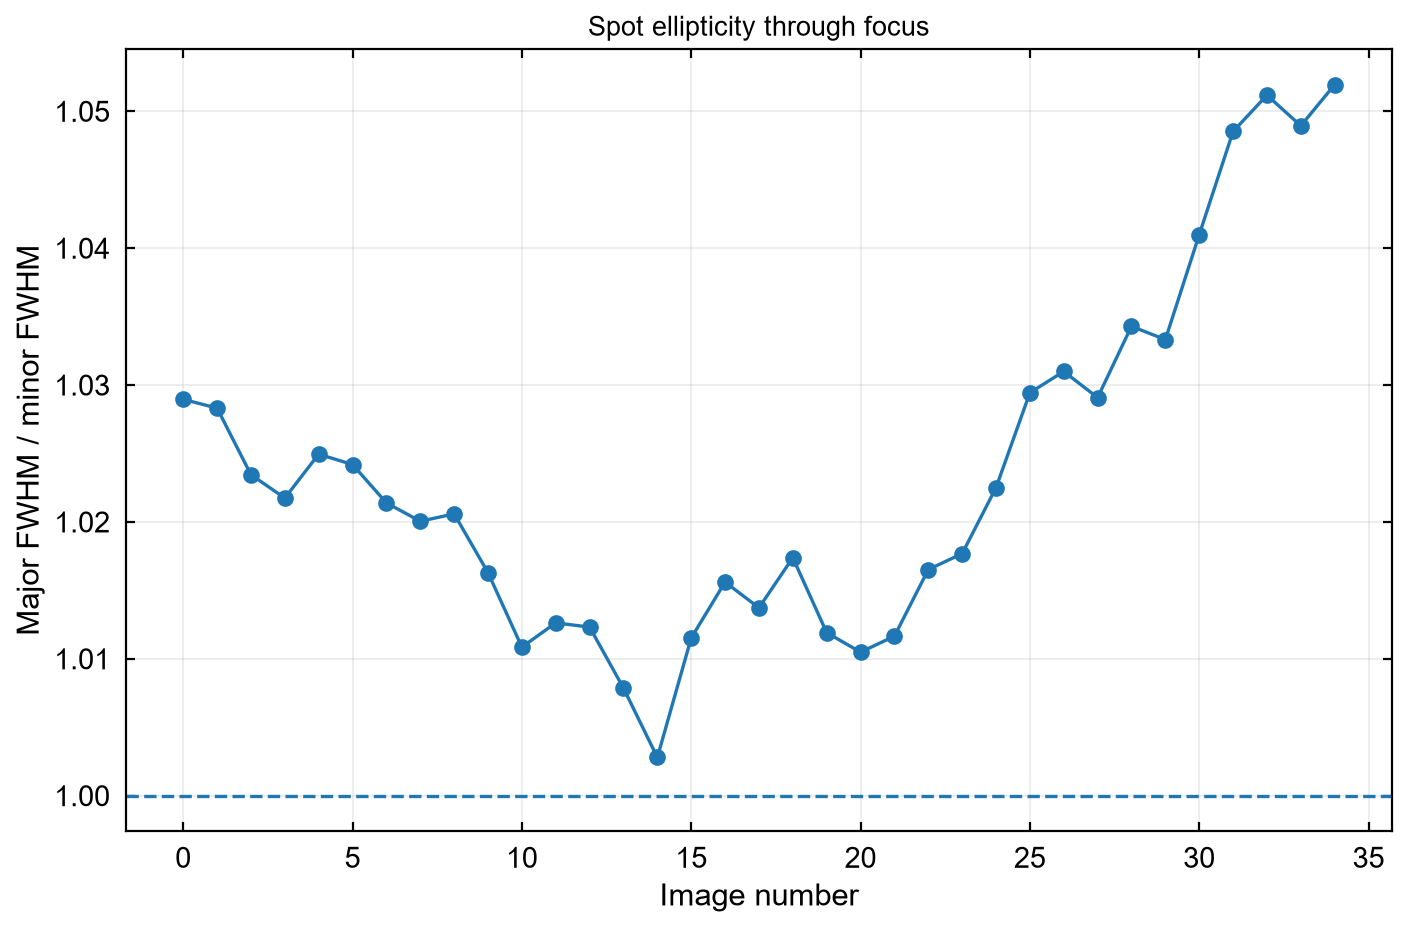

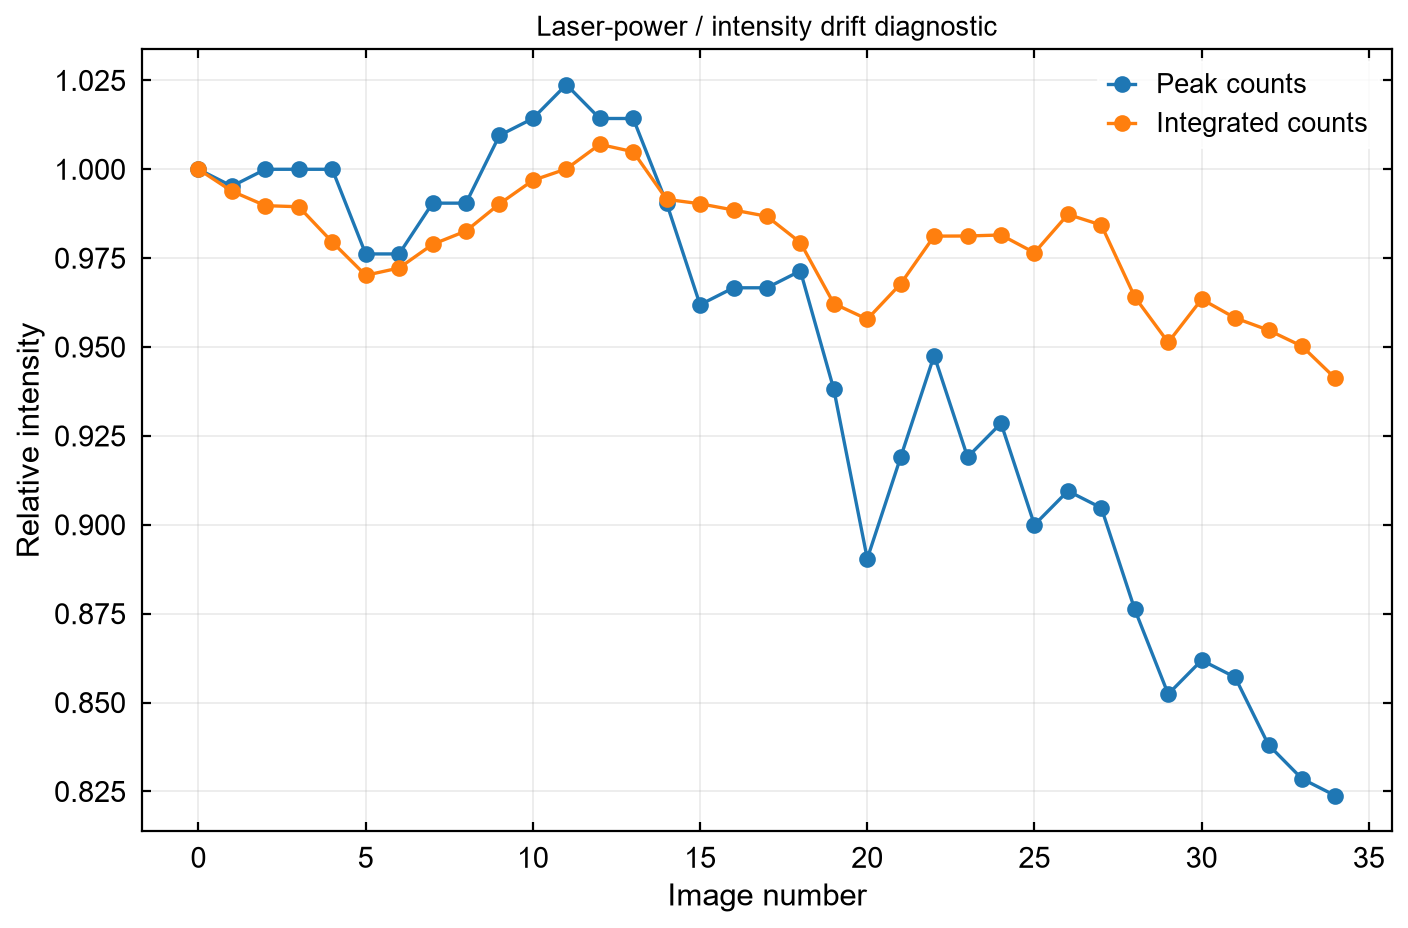

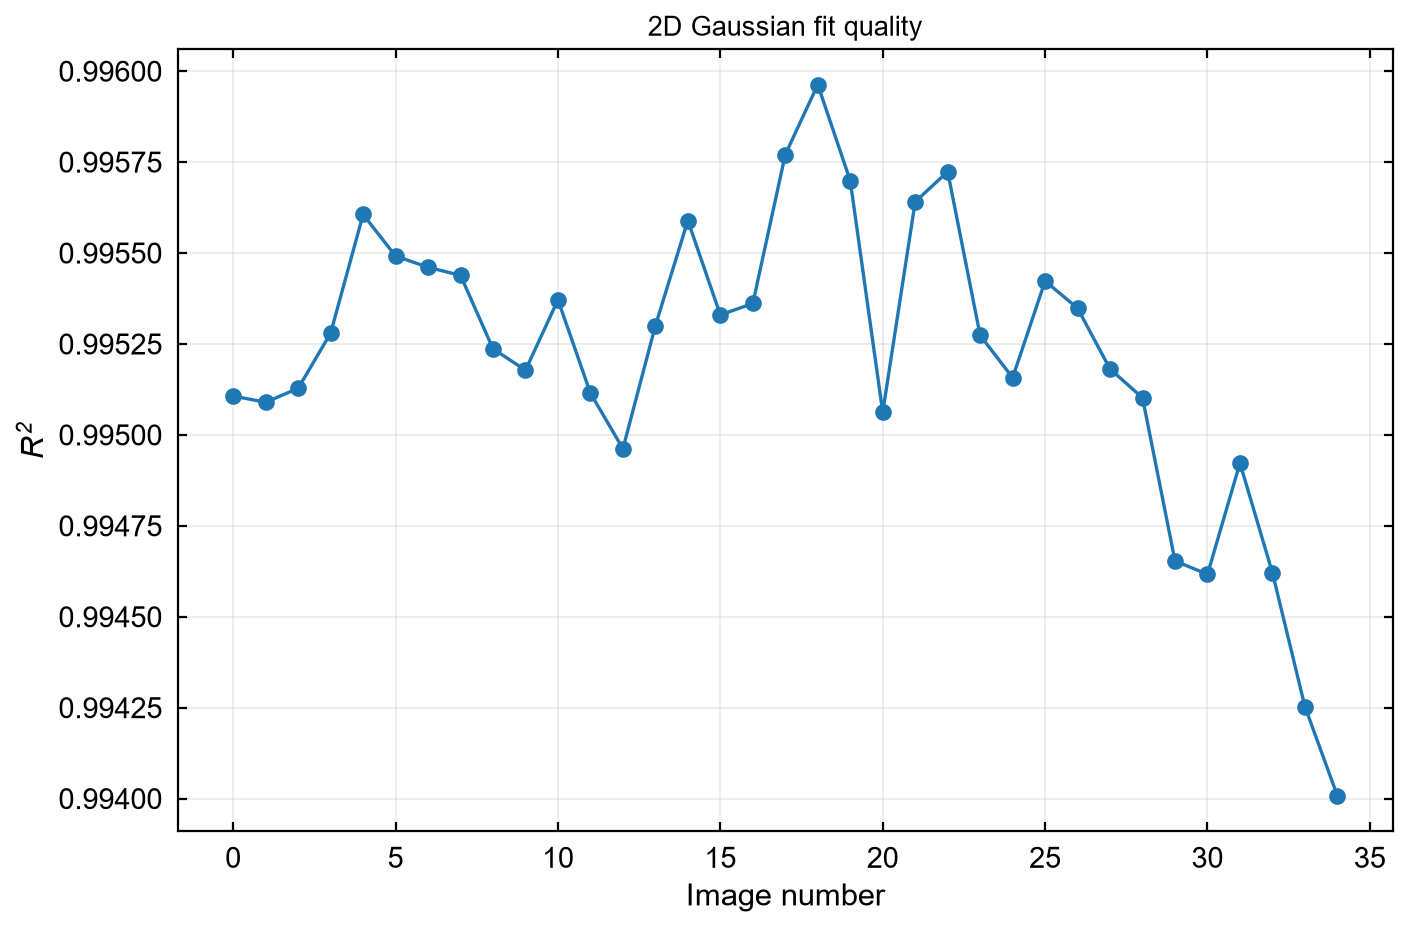


  frame  x_center_px  y_center_px  FWHM_x_um  FWHM_y_um  FWHM_geom_um  ellipticity  fit_R2  effective_area_px2  edge_flag
 0.0000     439.4849      84.2562    79.0779    76.9554       78.0095       1.0290  0.9951           2167.3231      False
 1.0000     429.2723      86.7054    79.1754    77.0752       78.1182       1.0283  0.9951           2166.9575      False
 2.0000     419.6751      89.2931    79.0156    77.2484       78.1270       1.0235  0.9951           2170.5283      False
 3.0000     410.4000      91.3264    78.8302    77.1698       77.9956       1.0217  0.9953           2165.4853      False
 4.0000     400.7316      93.8891    78.8113    76.8950       77.8472       1.0250  0.9956           2161.9958      False
 5.0000     391.5178      95.9862    78.7448    76.8942       77.8140       1.0242  0.9955           2161.1014      False
 6.0000     382.1161      98.6368    78.7294    77.0843       77.9025       1.0214  0.9955           2161.4546      False
 7.0000     372.2632   

In [4]:
# ============================================================
# FULL Z-SCAN ANALYSIS OF SLM FOCAL SPOT
# ============================================================
#
# Designed for images named:
#
#   0.tiff
#   1.tiff
#   2.tiff
#   ...
#   33.tiff
#
# Handles:
#   - spot translation as camera moves
#   - laser power drift
#   - x/y astigmatism
#   - non-perfect Gaussian spot
#
# Outputs:
#   - Gaussian FWHM_x and FWHM_y
#   - geometric-mean FWHM
#   - second-moment widths
#   - effective spot area
#   - centroid motion
#   - fit quality
#   - best-focus frame
#   - quadratic estimate of minimum
#   - CSV with all results
#
# ============================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from scipy.optimize import least_squares
from scipy.ndimage import gaussian_filter


# ============================================================
# USER SETTINGS
# ============================================================

FOLDER = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\Alignment\02Sept\z-scan"
)

CAMERA_PIXEL_UM = 2.4


# ------------------------------------------------------------
# Z calibration
# ------------------------------------------------------------
#
# If images are separated by a known translation-stage step,
# put it here.
#
# Example:
# Z_STEP_MM = 0.25
#
# If you do not know / care yet:
# Z_STEP_MM = None
#
# Then plots use image number as z coordinate.
# ------------------------------------------------------------

Z_STEP_MM = None

# Physical position corresponding to image 0
Z0_MM = 0.0


# ------------------------------------------------------------
# ROI around automatically detected spot
# ------------------------------------------------------------

ROI_HALF_X = 70
ROI_HALF_Y = 50


# ------------------------------------------------------------
# Gaussian blur used ONLY to find the spot center
# ------------------------------------------------------------

CENTER_BLUR_SIGMA = 2.0


# ------------------------------------------------------------
# Core fraction used for moment analysis
#
# Pixels below this fraction of peak signal are excluded
# from moment calculation.
#
# Helps suppress background noise.
# ------------------------------------------------------------

MOMENT_THRESHOLD = 0.02


# ============================================================
# HELPER: NUMBER FROM FILENAME
# ============================================================

def image_number(path):

    match = re.search(
        r"[-+]?\d*\.?\d+",
        path.stem
    )

    if match is None:
        return None

    return float(match.group())


# ============================================================
# LOAD IMAGE
# ============================================================

def load_image(path):

    img = np.array(
        Image.open(path),
        dtype=float
    )

    if img.ndim == 3:
        img = img.mean(axis=2)

    return img


# ============================================================
# BACKGROUND ESTIMATE
# ============================================================

def estimate_background(img):
    """
    Robust estimate from low-intensity part of image.

    We avoid using the peak or overall mean because the
    optical power may drift.
    """

    return np.percentile(img, 20)


# ============================================================
# FIND SPOT CENTER
# ============================================================

def find_spot_center(img, background):

    signal = img - background

    signal[signal < 0] = 0

    # Smooth only for finding the peak
    smooth = gaussian_filter(
        signal,
        CENTER_BLUR_SIGMA
    )

    y_peak, x_peak = np.unravel_index(
        np.argmax(smooth),
        smooth.shape
    )

    # Refine center with local intensity centroid
    search_half_x = 50
    search_half_y = 50

    y1 = max(
        0,
        y_peak - search_half_y
    )

    y2 = min(
        img.shape[0],
        y_peak + search_half_y + 1
    )

    x1 = max(
        0,
        x_peak - search_half_x
    )

    x2 = min(
        img.shape[1],
        x_peak + search_half_x + 1
    )

    local = signal[
        y1:y2,
        x1:x2
    ]

    yy, xx = np.indices(
        local.shape
    )

    # Remove very weak background
    threshold = (
        0.03 * local.max()
    )

    weights = np.where(
        local > threshold,
        local,
        0
    )

    total = weights.sum()

    if total <= 0:

        return (
            float(x_peak),
            float(y_peak)
        )

    x_local = (
        (xx * weights).sum()
        / total
    )

    y_local = (
        (yy * weights).sum()
        / total
    )

    x_center = x1 + x_local
    y_center = y1 + y_local

    return x_center, y_center


# ============================================================
# CROP AROUND MOVING SPOT
# ============================================================

def crop_around_spot(
    img,
    x_center,
    y_center
):

    xc = int(round(x_center))
    yc = int(round(y_center))

    x1 = max(
        0,
        xc - ROI_HALF_X
    )

    x2 = min(
        img.shape[1],
        xc + ROI_HALF_X + 1
    )

    y1 = max(
        0,
        yc - ROI_HALF_Y
    )

    y2 = min(
        img.shape[0],
        yc + ROI_HALF_Y + 1
    )

    roi = img[
        y1:y2,
        x1:x2
    ]

    # Flag whether the desired ROI hit image boundary
    edge_flag = (
        x1 == 0
        or y1 == 0
        or x2 == img.shape[1]
        or y2 == img.shape[0]
    )

    return (
        roi,
        x1,
        y1,
        edge_flag
    )


# ============================================================
# ROTATED 2D GAUSSIAN
# ============================================================

def gaussian_2d(
    params,
    xx,
    yy
):

    (
        amplitude,
        x0,
        y0,
        sigma_1,
        sigma_2,
        theta,
        background
    ) = params

    c = np.cos(theta)
    s = np.sin(theta)

    dx = xx - x0
    dy = yy - y0

    # Rotate into principal axes
    xp = (
        c * dx
        + s * dy
    )

    yp = (
        -s * dx
        + c * dy
    )

    exponent = (
        -0.5
        * (
            (xp / sigma_1)**2
            +
            (yp / sigma_2)**2
        )
    )

    return (
        background
        +
        amplitude
        * np.exp(exponent)
    )


# ============================================================
# FIT 2D GAUSSIAN
# ============================================================

def fit_gaussian_2d(roi):

    ny, nx = roi.shape

    yy, xx = np.indices(
        roi.shape
    )

    bg0 = np.percentile(
        roi,
        10
    )

    signal = roi - bg0

    signal[signal < 0] = 0

    total = signal.sum()

    # --------------------------------------------------------
    # Initial centroid
    # --------------------------------------------------------

    x0 = (
        (xx * signal).sum()
        / total
    )

    y0 = (
        (yy * signal).sum()
        / total
    )

    # --------------------------------------------------------
    # Initial widths
    # --------------------------------------------------------

    sigma_x0 = np.sqrt(
        (
            signal
            * (xx - x0)**2
        ).sum()
        / total
    )

    sigma_y0 = np.sqrt(
        (
            signal
            * (yy - y0)**2
        ).sum()
        / total
    )

    sigma_x0 = max(
        sigma_x0,
        2.0
    )

    sigma_y0 = max(
        sigma_y0,
        2.0
    )

    amplitude0 = (
        roi.max()
        - bg0
    )

    p0 = np.array([
        amplitude0,
        x0,
        y0,
        sigma_x0,
        sigma_y0,
        0.0,
        bg0
    ])


    # --------------------------------------------------------
    # Bounds
    # --------------------------------------------------------

    lower = np.array([
        0,
        0,
        0,
        0.5,
        0.5,
        -np.pi / 2,
        -np.inf
    ])

    upper = np.array([
        np.inf,
        nx - 1,
        ny - 1,
        100,
        100,
        np.pi / 2,
        np.inf
    ])


    # --------------------------------------------------------
    # Residual
    # --------------------------------------------------------

    def residual(params):

        model = gaussian_2d(
            params,
            xx,
            yy
        )

        return (
            model - roi
        ).ravel()


    result = least_squares(
        residual,
        p0,
        bounds=(lower, upper),
        max_nfev=10000
    )

    params = result.x

    model = gaussian_2d(
        params,
        xx,
        yy
    )


    # --------------------------------------------------------
    # Fit R^2
    # --------------------------------------------------------

    ss_res = np.sum(
        (roi - model)**2
    )

    ss_tot = np.sum(
        (
            roi
            - np.mean(roi)
        )**2
    )

    if ss_tot > 0:

        r2 = (
            1
            - ss_res / ss_tot
        )

    else:

        r2 = np.nan


    return (
        params,
        model,
        r2
    )


# ============================================================
# CONVERT ROTATED GAUSSIAN TO CAMERA X/Y WIDTHS
# ============================================================

def gaussian_lab_widths(
    sigma_1,
    sigma_2,
    theta
):

    c = np.cos(theta)
    s = np.sin(theta)

    # Covariance projected onto camera x/y axes

    var_x = (
        sigma_1**2 * c**2
        +
        sigma_2**2 * s**2
    )

    var_y = (
        sigma_1**2 * s**2
        +
        sigma_2**2 * c**2
    )

    sigma_x = np.sqrt(
        var_x
    )

    sigma_y = np.sqrt(
        var_y
    )

    return sigma_x, sigma_y


# ============================================================
# NON-PARAMETRIC MOMENTS
# ============================================================

def moment_analysis(
    roi,
    background
):

    signal = (
        roi - background
    )

    signal[
        signal < 0
    ] = 0

    peak = signal.max()

    mask = (
        signal
        >= MOMENT_THRESHOLD * peak
    )

    weights = np.where(
        mask,
        signal,
        0
    )

    total = weights.sum()

    yy, xx = np.indices(
        roi.shape
    )

    x0 = (
        (xx * weights).sum()
        / total
    )

    y0 = (
        (yy * weights).sum()
        / total
    )

    dx = xx - x0
    dy = yy - y0

    var_x = (
        (weights * dx**2).sum()
        / total
    )

    var_y = (
        (weights * dy**2).sum()
        / total
    )

    cov_xy = (
        (weights * dx * dy).sum()
        / total
    )

    covariance = np.array([
        [var_x, cov_xy],
        [cov_xy, var_y]
    ])

    eigenvalues = np.linalg.eigvalsh(
        covariance
    )

    eigenvalues = np.sort(
        eigenvalues
    )

    sigma_minor = np.sqrt(
        eigenvalues[0]
    )

    sigma_major = np.sqrt(
        eigenvalues[1]
    )

    # --------------------------------------------------------
    # Effective area:
    #
    # A_eff = (sum I)^2 / sum(I^2)
    #
    # Multiplying the whole image by arbitrary laser power
    # leaves this unchanged.
    # --------------------------------------------------------

    effective_area_px2 = (
        total**2
        /
        np.sum(weights**2)
    )

    # sqrt(det(C)) is another area-like width metric
    moment_area = np.sqrt(
        np.linalg.det(
            covariance
        )
    )

    return {
        "moment_sigma_x_px":
            np.sqrt(var_x),

        "moment_sigma_y_px":
            np.sqrt(var_y),

        "moment_sigma_minor_px":
            sigma_minor,

        "moment_sigma_major_px":
            sigma_major,

        "moment_area_px2":
            moment_area,

        "effective_area_px2":
            effective_area_px2
    }


# ============================================================
# ANALYSE ONE IMAGE
# ============================================================

def analyse_one(path):

    frame = image_number(
        path
    )

    img = load_image(
        path
    )

    background = estimate_background(
        img
    )

    # --------------------------------------------------------
    # Track moving spot
    # --------------------------------------------------------

    x_center_guess, y_center_guess = (
        find_spot_center(
            img,
            background
        )
    )

    roi, x_offset, y_offset, edge_flag = (
        crop_around_spot(
            img,
            x_center_guess,
            y_center_guess
        )
    )

    # --------------------------------------------------------
    # 2D Gaussian fit
    # --------------------------------------------------------

    params, model, r2 = (
        fit_gaussian_2d(
            roi
        )
    )

    (
        amplitude,
        x0_roi,
        y0_roi,
        sigma_1,
        sigma_2,
        theta,
        fit_background
    ) = params


    # Convert center back to full camera coordinates

    x_center = (
        x_offset
        + x0_roi
    )

    y_center = (
        y_offset
        + y0_roi
    )


    # --------------------------------------------------------
    # Widths projected onto camera X/Y
    # --------------------------------------------------------

    sigma_x, sigma_y = (
        gaussian_lab_widths(
            sigma_1,
            sigma_2,
            theta
        )
    )


    gaussian_factor = (
        2 * np.sqrt(
            2 * np.log(2)
        )
    )

    fwhm_x_px = (
        gaussian_factor
        * sigma_x
    )

    fwhm_y_px = (
        gaussian_factor
        * sigma_y
    )


    fwhm_x_um = (
        fwhm_x_px
        * CAMERA_PIXEL_UM
    )

    fwhm_y_um = (
        fwhm_y_px
        * CAMERA_PIXEL_UM
    )


    fwhm_geom_um = np.sqrt(
        fwhm_x_um
        * fwhm_y_um
    )


    # Principal-axis FWHMs

    fwhm_1_um = (
        gaussian_factor
        * sigma_1
        * CAMERA_PIXEL_UM
    )

    fwhm_2_um = (
        gaussian_factor
        * sigma_2
        * CAMERA_PIXEL_UM
    )

    fwhm_major_um = max(
        fwhm_1_um,
        fwhm_2_um
    )

    fwhm_minor_um = min(
        fwhm_1_um,
        fwhm_2_um
    )


    ellipticity = (
        fwhm_major_um
        /
        fwhm_minor_um
    )


    # --------------------------------------------------------
    # Fit-independent moment analysis
    # --------------------------------------------------------

    moments = moment_analysis(
        roi,
        background
    )


    # --------------------------------------------------------
    # Power diagnostics
    # --------------------------------------------------------

    signal_roi = (
        roi - background
    )

    signal_roi[
        signal_roi < 0
    ] = 0

    integrated_counts = (
        signal_roi.sum()
    )

    peak_counts = (
        signal_roi.max()
    )


    return {
        "filename":
            path.name,

        "frame":
            frame,

        "x_center_px":
            x_center,

        "y_center_px":
            y_center,

        "amplitude":
            amplitude,

        "peak_counts":
            peak_counts,

        "integrated_counts":
            integrated_counts,

        "FWHM_x_um":
            fwhm_x_um,

        "FWHM_y_um":
            fwhm_y_um,

        "FWHM_geom_um":
            fwhm_geom_um,

        "FWHM_major_um":
            fwhm_major_um,

        "FWHM_minor_um":
            fwhm_minor_um,

        "ellipticity":
            ellipticity,

        "theta_deg":
            np.degrees(theta),

        "fit_R2":
            r2,

        "edge_flag":
            edge_flag,

        **moments
    }


# ============================================================
# FIND ALL IMAGES
# ============================================================

extensions = {
    ".tif",
    ".tiff",
    ".bmp",
    ".png",
    ".jpg",
    ".jpeg"
}

files = []

for path in FOLDER.iterdir():

    if (
        path.suffix.lower()
        not in extensions
    ):
        continue

    n = image_number(
        path
    )

    if n is None:
        continue

    files.append(
        path
    )


files.sort(
    key=image_number
)


print(
    f"Found {len(files)} images."
)

for f in files:

    print(
        f"{image_number(f):6.2f} : {f.name}"
    )


# ============================================================
# ANALYSE ALL IMAGES
# ============================================================

results = []

for i, path in enumerate(files):

    print(
        f"Analysing "
        f"{i+1}/{len(files)} : "
        f"{path.name}"
    )

    try:

        result = analyse_one(
            path
        )

        results.append(
            result
        )

    except Exception as exc:

        print(
            "FAILED:",
            path.name,
            exc
        )


df = pd.DataFrame(
    results
)

df = df.sort_values(
    "frame"
).reset_index(
    drop=True
)


# ============================================================
# CREATE Z COORDINATE
# ============================================================

if Z_STEP_MM is None:

    df["z"] = (
        df["frame"]
    )

    z_label = (
        "Image number"
    )

    z_unit = (
        "frames"
    )

else:

    df["z"] = (
        Z0_MM
        +
        df["frame"]
        * Z_STEP_MM
    )

    z_label = (
        "Camera z position [mm]"
    )

    z_unit = (
        "mm"
    )


# ============================================================
# QUADRATIC MINIMUM
# ============================================================

def quadratic_minimum(
    x,
    y,
    points_each_side=2
):
    """
    Find discrete minimum, then fit a quadratic to a local
    neighborhood around it.

    Returns:
        discrete x
        discrete y
        fitted minimum x
        fitted minimum y
        success flag
    """

    x = np.asarray(
        x,
        dtype=float
    )

    y = np.asarray(
        y,
        dtype=float
    )

    finite = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )

    x = x[finite]
    y = y[finite]

    i_min = np.argmin(
        y
    )

    x_discrete = x[i_min]
    y_discrete = y[i_min]

    i1 = max(
        0,
        i_min - points_each_side
    )

    i2 = min(
        len(x),
        i_min + points_each_side + 1
    )

    xx = x[i1:i2]
    yy = y[i1:i2]


    # Minimum at boundary cannot be trusted
    if (
        i_min == 0
        or
        i_min == len(x) - 1
        or
        len(xx) < 3
    ):

        return (
            x_discrete,
            y_discrete,
            np.nan,
            np.nan,
            False
        )


    coeff = np.polyfit(
        xx,
        yy,
        2
    )

    a, b, c = coeff


    # Must curve upward
    if a <= 0:

        return (
            x_discrete,
            y_discrete,
            np.nan,
            np.nan,
            False
        )


    x_fit_min = (
        -b
        /
        (2 * a)
    )

    y_fit_min = np.polyval(
        coeff,
        x_fit_min
    )


    # Do not trust extrapolated result outside local data
    if (
        x_fit_min < xx.min()
        or
        x_fit_min > xx.max()
    ):

        return (
            x_discrete,
            y_discrete,
            np.nan,
            np.nan,
            False
        )


    return (
        x_discrete,
        y_discrete,
        x_fit_min,
        y_fit_min,
        True
    )


# ============================================================
# FIND IMPORTANT MINIMA
# ============================================================

metrics = {
    "X Gaussian FWHM":
        "FWHM_x_um",

    "Y Gaussian FWHM":
        "FWHM_y_um",

    "Geometric-mean FWHM":
        "FWHM_geom_um",

    "Moment area":
        "moment_area_px2",

    "Effective area":
        "effective_area_px2"
}


print()
print(
    "=" * 75
)

print(
    "FOCUS RESULTS"
)

print(
    "=" * 75
)


focus_results = {}


for label, column in metrics.items():

    result = quadratic_minimum(
        df["z"],
        df[column]
    )

    focus_results[column] = result

    (
        x_disc,
        y_disc,
        x_fit,
        y_fit,
        success
    ) = result

    print()
    print(label)

    print(
        f"  discrete minimum : "
        f"z = {x_disc:.4f} {z_unit}"
    )

    print(
        f"  value            : "
        f"{y_disc:.4f}"
    )

    if success:

        print(
            f"  quadratic min    : "
            f"z = {x_fit:.4f} {z_unit}"
        )

        print(
            f"  interpolated val : "
            f"{y_fit:.4f}"
        )

    else:

        print(
            "  quadratic minimum could not "
            "be determined reliably."
        )


# ============================================================
# ASTIGMATISM ESTIMATE
# ============================================================

x_result = (
    focus_results[
        "FWHM_x_um"
    ]
)

y_result = (
    focus_results[
        "FWHM_y_um"
    ]
)


if (
    x_result[4]
    and
    y_result[4]
):

    zx = x_result[2]
    zy = y_result[2]

    separation = (
        zx - zy
    )

    print()
    print(
        "=" * 75
    )

    print(
        "X/Y FOCAL SEPARATION"
    )

    print(
        "=" * 75
    )

    print(
        f"X focus : "
        f"{zx:.4f} {z_unit}"
    )

    print(
        f"Y focus : "
        f"{zy:.4f} {z_unit}"
    )

    print(
        f"X - Y   : "
        f"{separation:.4f} {z_unit}"
    )


# ============================================================
# SAVE CSV
# ============================================================

csv_path = (
    FOLDER
    /
    "zscan_analysis.csv"
)

df.to_csv(
    csv_path,
    index=False
)

print()
print(
    "Saved:"
)

print(
    csv_path
)


# ============================================================
# PLOT 1:
# GAUSSIAN FWHM
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    df["z"],
    df["FWHM_x_um"],
    "o-",
    label="FWHM X"
)

plt.plot(
    df["z"],
    df["FWHM_y_um"],
    "o-",
    label="FWHM Y"
)

plt.plot(
    df["z"],
    df["FWHM_geom_um"],
    "o--",
    label="Geometric mean"
)

plt.xlabel(
    z_label
)

plt.ylabel(
    "Gaussian FWHM [um]"
)

plt.title(
    "Spot size through focus"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 2:
# NORMALIZED WIDTHS
#
# Useful because absolute spot size can be very different
# in X and Y.
# ============================================================

plt.figure(
    figsize=(9, 6)
)

x_norm = (
    df["FWHM_x_um"]
    /
    df["FWHM_x_um"].min()
)

y_norm = (
    df["FWHM_y_um"]
    /
    df["FWHM_y_um"].min()
)

plt.plot(
    df["z"],
    x_norm,
    "o-",
    label="X / Xmin"
)

plt.plot(
    df["z"],
    y_norm,
    "o-",
    label="Y / Ymin"
)

plt.axhline(
    1,
    linestyle="--"
)

plt.xlabel(
    z_label
)

plt.ylabel(
    "Width / minimum width"
)

plt.title(
    "Normalized focus curves"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 3:
# FIT-INDEPENDENT AREA METRICS
# ============================================================

plt.figure(
    figsize=(9, 6)
)

moment_norm = (
    df["moment_area_px2"]
    /
    df["moment_area_px2"].min()
)

effective_norm = (
    df["effective_area_px2"]
    /
    df["effective_area_px2"].min()
)

plt.plot(
    df["z"],
    moment_norm,
    "o-",
    label="Moment area"
)

plt.plot(
    df["z"],
    effective_norm,
    "o-",
    label="Effective area"
)

plt.axhline(
    1,
    linestyle="--"
)

plt.xlabel(
    z_label
)

plt.ylabel(
    "Normalized area"
)

plt.title(
    "Fit-independent focus metrics"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 4:
# CENTROID MOTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)

x0 = (
    df["x_center_px"].iloc[0]
)

y0 = (
    df["y_center_px"].iloc[0]
)

plt.plot(
    df["z"],
    df["x_center_px"] - x0,
    "o-",
    label="X centroid"
)

plt.plot(
    df["z"],
    df["y_center_px"] - y0,
    "o-",
    label="Y centroid"
)

plt.xlabel(
    z_label
)

plt.ylabel(
    "Centroid displacement [pixel]"
)

plt.title(
    "Spot translation during camera z scan"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 5:
# ELLIPTICITY
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    df["z"],
    df["ellipticity"],
    "o-"
)

plt.axhline(
    1,
    linestyle="--"
)

plt.xlabel(
    z_label
)

plt.ylabel(
    "Major FWHM / minor FWHM"
)

plt.title(
    "Spot ellipticity through focus"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 6:
# LASER POWER DRIFT DIAGNOSTIC
#
# These quantities are NOT used to determine focus.
# ============================================================

plt.figure(
    figsize=(9, 6)
)

peak_norm = (
    df["peak_counts"]
    /
    df["peak_counts"].iloc[0]
)

power_norm = (
    df["integrated_counts"]
    /
    df["integrated_counts"].iloc[0]
)

plt.plot(
    df["z"],
    peak_norm,
    "o-",
    label="Peak counts"
)

plt.plot(
    df["z"],
    power_norm,
    "o-",
    label="Integrated counts"
)

plt.xlabel(
    z_label
)

plt.ylabel(
    "Relative intensity"
)

plt.title(
    "Laser-power / intensity drift diagnostic"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 7:
# FIT QUALITY
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.plot(
    df["z"],
    df["fit_R2"],
    "o-"
)

plt.xlabel(
    z_label
)

plt.ylabel(
    r"$R^2$"
)

plt.title(
    "2D Gaussian fit quality"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# PRINT COMPACT TABLE
# ============================================================

show_columns = [
    "frame",
    "x_center_px",
    "y_center_px",
    "FWHM_x_um",
    "FWHM_y_um",
    "FWHM_geom_um",
    "ellipticity",
    "fit_R2",
    "effective_area_px2",
    "edge_flag"
]

print()
print(
    df[
        show_columns
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:.4f}"
    )
)

Found 35 images
Analysing: 0.tiff
Analysing: 1.tiff
Analysing: 2.tiff
Analysing: 3.tiff
Analysing: 4.tiff
Analysing: 5.tiff
Analysing: 6.tiff
Analysing: 7.tiff
Analysing: 8.tiff
Analysing: 9.tiff
Analysing: 10.tiff
Analysing: 11.tiff
Analysing: 12.tiff
Analysing: 13.tiff
Analysing: 14.tiff
Analysing: 15.tiff
Analysing: 16.tiff
Analysing: 17.tiff
Analysing: 18.tiff
Analysing: 19.tiff
Analysing: 20.tiff
Analysing: 21.tiff
Analysing: 22.tiff
Analysing: 23.tiff
Analysing: 24.tiff
Analysing: 25.tiff
Analysing: 26.tiff
Analysing: 27.tiff
Analysing: 28.tiff
Analysing: 29.tiff
Analysing: 30.tiff
Analysing: 31.tiff
Analysing: 32.tiff
Analysing: 33.tiff
Analysing: 34.tiff


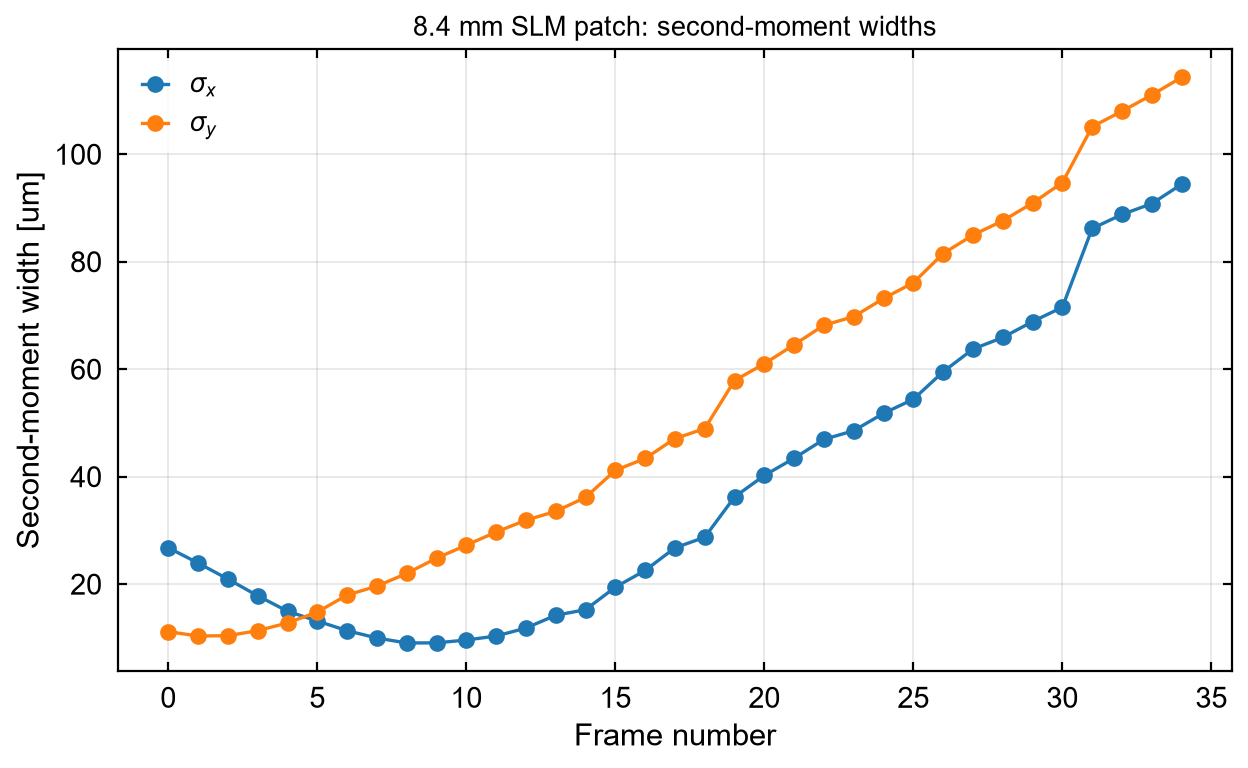

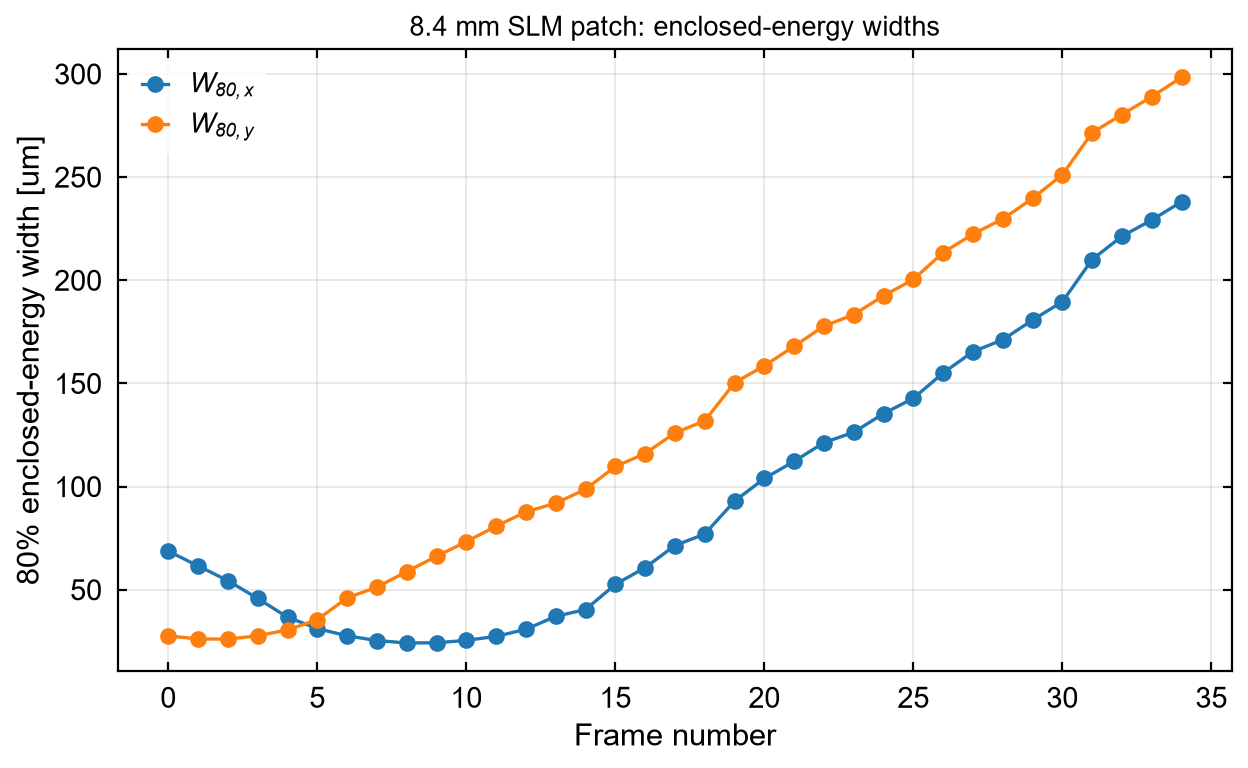

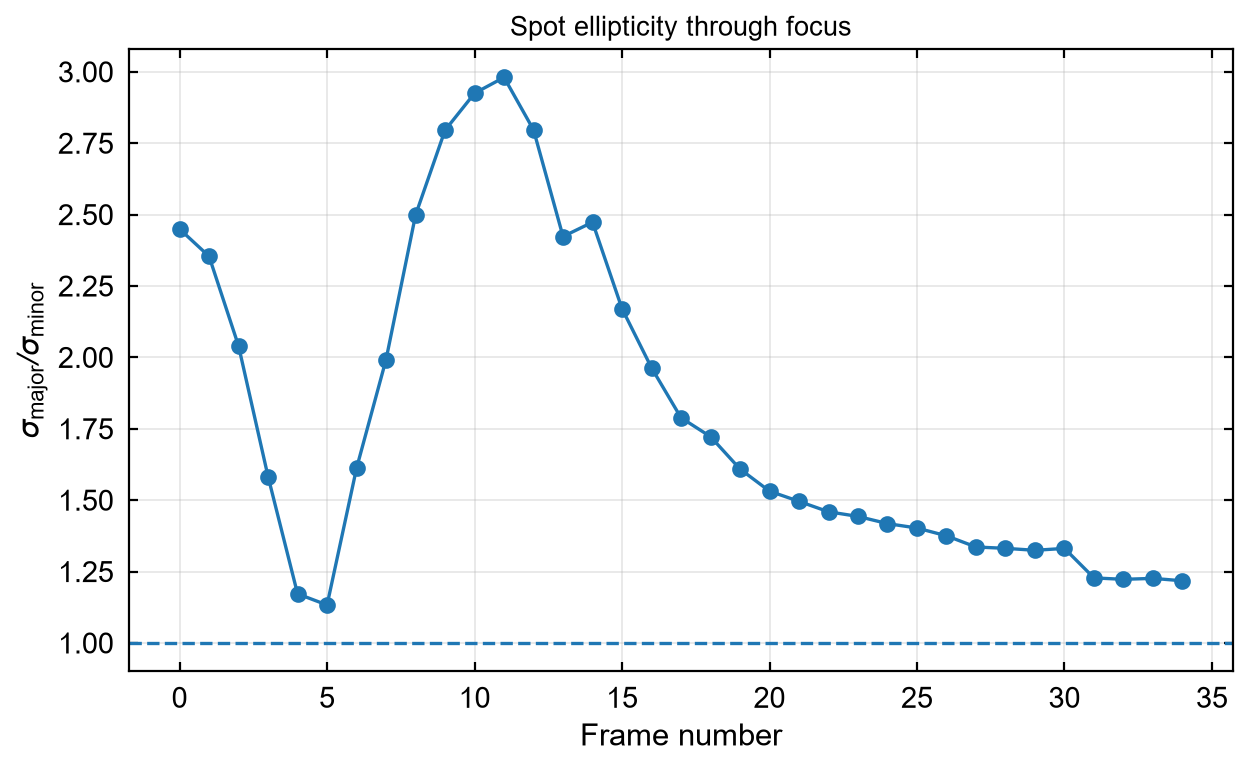

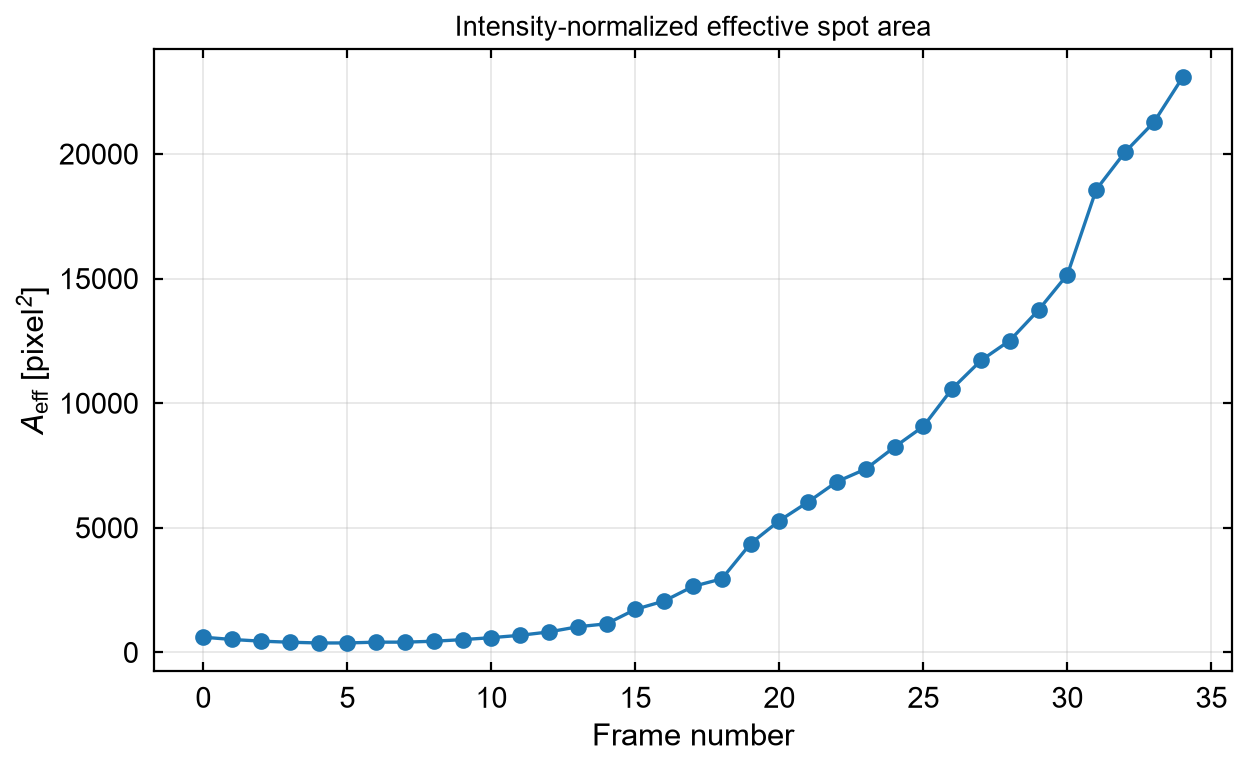


MINIMA
sigma_x_um            : frame 8, value = 9.054
sigma_y_um            : frame 1, value = 10.348
W80_x_um              : frame 8, value = 24.220
W80_y_um              : frame 2, value = 26.085
effective_area_px2    : frame 4, value = 379.578

 frame  sigma_x_um  sigma_y_um  W80_x_um  W80_y_um  ellipticity  effective_area_px2
     0      26.780      11.158    68.682    27.630        2.450             610.907
     1      23.926      10.348    61.609    26.168        2.354             519.167
     2      20.947      10.410    54.390    26.085        2.040             452.036
     3      17.834      11.346    45.805    27.713        1.582             409.331
     4      14.966      12.785    36.700    30.535        1.172             379.578
     5      13.134      14.806    31.199    35.520        1.133             380.397
     6      11.339      17.974    27.682    46.065        1.612             411.825
     7       9.973      19.624    25.390    51.311        1.993             412

In [5]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image


# ============================================================
# USER SETTINGS
# ============================================================

FOLDER = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\Alignment\02Sept\z-scan-patch8.4"
)

PIXEL_UM = 2.4

# Put real stage step here if known.
# Example: 0.25
Z_STEP_MM = None


# ============================================================
# HELPERS
# ============================================================

def frame_number(path):
    m = re.search(r"\d+", path.stem)

    if m is None:
        return None

    return int(m.group())


def load_image(path):

    img = np.array(
        Image.open(path),
        dtype=float
    )

    if img.ndim == 3:
        img = img.mean(axis=2)

    return img


def background_from_border(img, border=10):

    b = np.concatenate([
        img[:border, :].ravel(),
        img[-border:, :].ravel(),
        img[:, :border].ravel(),
        img[:, -border:].ravel(),
    ])

    bg = np.median(b)

    mad = np.median(
        np.abs(b - bg)
    )

    noise = 1.4826 * mad

    # Handle highly quantized images where MAD = 0
    if noise == 0:
        noise = max(
            np.std(b),
            0.5
        )

    return bg, noise


# ============================================================
# QUANTILE WIDTH
# ============================================================

def quantile_width(probability, fraction=0.80):

    p = np.asarray(
        probability,
        dtype=float
    )

    p /= p.sum()

    cdf = np.cumsum(p)

    q_low = (1 - fraction) / 2
    q_high = 1 - q_low

    coordinate = np.arange(
        len(p)
    )

    x_low = np.interp(
        q_low,
        cdf,
        coordinate
    )

    x_high = np.interp(
        q_high,
        cdf,
        coordinate
    )

    return x_high - x_low


# ============================================================
# ANALYSE ONE IMAGE
# ============================================================

def analyse_image(path):

    img = load_image(path)

    bg, noise = background_from_border(
        img
    )

    signal = img - bg

    signal[
        signal < 0
    ] = 0


    # --------------------------------------------------------
    # Suppress background noise
    # --------------------------------------------------------

    threshold = max(
        3 * noise,
        1.0
    )

    weights = np.where(
        signal >= threshold,
        signal,
        0
    )


    # --------------------------------------------------------
    # Normalize:
    # removes multiplicative laser-power drift
    # --------------------------------------------------------

    total = weights.sum()

    if total <= 0:
        raise RuntimeError(
            f"No usable signal in {path.name}"
        )

    p = weights / total


    # --------------------------------------------------------
    # Centroid
    # --------------------------------------------------------

    yy, xx = np.indices(
        img.shape
    )

    xc = np.sum(
        p * xx
    )

    yc = np.sum(
        p * yy
    )


    # --------------------------------------------------------
    # Second moments
    # --------------------------------------------------------

    dx = xx - xc
    dy = yy - yc

    var_x = np.sum(
        p * dx**2
    )

    var_y = np.sum(
        p * dy**2
    )

    cov_xy = np.sum(
        p * dx * dy
    )

    sigma_x_px = np.sqrt(
        var_x
    )

    sigma_y_px = np.sqrt(
        var_y
    )


    # --------------------------------------------------------
    # Principal axes
    # --------------------------------------------------------

    covariance = np.array([
        [var_x, cov_xy],
        [cov_xy, var_y]
    ])

    eigvals, eigvecs = np.linalg.eigh(
        covariance
    )

    eigvals = np.sort(
        eigvals
    )

    sigma_minor_px = np.sqrt(
        eigvals[0]
    )

    sigma_major_px = np.sqrt(
        eigvals[1]
    )

    ellipticity = (
        sigma_major_px
        /
        sigma_minor_px
    )


    # --------------------------------------------------------
    # Marginals
    # --------------------------------------------------------

    px = np.sum(
        p,
        axis=0
    )

    py = np.sum(
        p,
        axis=1
    )


    W80_x_px = quantile_width(
        px,
        fraction=0.80
    )

    W80_y_px = quantile_width(
        py,
        fraction=0.80
    )


    W50_x_px = quantile_width(
        px,
        fraction=0.50
    )

    W50_y_px = quantile_width(
        py,
        fraction=0.50
    )


    # --------------------------------------------------------
    # Effective area
    #
    # invariant under:
    #
    # I -> a I
    #
    # --------------------------------------------------------

    effective_area_px2 = (
        weights.sum()**2
        /
        np.sum(weights**2)
    )


    return {
        "frame":
            frame_number(path),

        "x_center_px":
            xc,

        "y_center_px":
            yc,

        "sigma_x_um":
            sigma_x_px * PIXEL_UM,

        "sigma_y_um":
            sigma_y_px * PIXEL_UM,

        "sigma_major_um":
            sigma_major_px * PIXEL_UM,

        "sigma_minor_um":
            sigma_minor_px * PIXEL_UM,

        "W50_x_um":
            W50_x_px * PIXEL_UM,

        "W50_y_um":
            W50_y_px * PIXEL_UM,

        "W80_x_um":
            W80_x_px * PIXEL_UM,

        "W80_y_um":
            W80_y_px * PIXEL_UM,

        "ellipticity":
            ellipticity,

        "effective_area_px2":
            effective_area_px2,

        # Only diagnostic because power drifted
        "integrated_counts":
            total,

        "peak_counts":
            signal.max(),
    }


# ============================================================
# LOAD ALL FILES
# ============================================================

files = []

for path in FOLDER.glob("*.tiff"):

    n = frame_number(path)

    if n is not None:
        files.append(path)


files.sort(
    key=frame_number
)


print(
    f"Found {len(files)} images"
)


# ============================================================
# ANALYSE
# ============================================================

results = []

for path in files:

    print(
        "Analysing:",
        path.name
    )

    results.append(
        analyse_image(path)
    )


df = pd.DataFrame(
    results
)

df = df.sort_values(
    "frame"
).reset_index(
    drop=True
)


# ============================================================
# Z AXIS
# ============================================================

if Z_STEP_MM is None:

    df["z"] = df["frame"]

    xlabel = "Frame number"

else:

    df["z"] = (
        df["frame"]
        * Z_STEP_MM
    )

    xlabel = "Camera z position [mm]"


# ============================================================
# SAVE
# ============================================================

df.to_csv(
    FOLDER / "8p4mm_zscan_model_independent.csv",
    index=False
)


# ============================================================
# PLOT 1 — SECOND-MOMENT WIDTHS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df["z"],
    df["sigma_x_um"],
    "o-",
    label=r"$\sigma_x$"
)

plt.plot(
    df["z"],
    df["sigma_y_um"],
    "o-",
    label=r"$\sigma_y$"
)

plt.xlabel(xlabel)

plt.ylabel(
    "Second-moment width [um]"
)

plt.title(
    "8.4 mm SLM patch: second-moment widths"
)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2 — 80% ENERGY WIDTH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df["z"],
    df["W80_x_um"],
    "o-",
    label=r"$W_{80,x}$"
)

plt.plot(
    df["z"],
    df["W80_y_um"],
    "o-",
    label=r"$W_{80,y}$"
)

plt.xlabel(xlabel)

plt.ylabel(
    "80% enclosed-energy width [um]"
)

plt.title(
    "8.4 mm SLM patch: enclosed-energy widths"
)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 3 — ELLIPTICITY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df["z"],
    df["ellipticity"],
    "o-"
)

plt.axhline(
    1,
    linestyle="--"
)

plt.xlabel(xlabel)

plt.ylabel(
    r"$\sigma_{\rm major}/\sigma_{\rm minor}$"
)

plt.title(
    "Spot ellipticity through focus"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 4 — EFFECTIVE AREA
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df["z"],
    df["effective_area_px2"],
    "o-"
)

plt.xlabel(xlabel)

plt.ylabel(
    r"$A_{\rm eff}$ [pixel$^2$]"
)

plt.title(
    "Intensity-normalized effective spot area"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# FIND DISCRETE MINIMA
# ============================================================

print()
print("=" * 60)
print("MINIMA")
print("=" * 60)

for col in [
    "sigma_x_um",
    "sigma_y_um",
    "W80_x_um",
    "W80_y_um",
    "effective_area_px2",
]:

    i = df[col].idxmin()

    print(
        f"{col:22s}: "
        f"frame {df.loc[i, 'frame']:g}, "
        f"value = {df.loc[i, col]:.3f}"
    )


# ============================================================
# PRINT TABLE
# ============================================================

print()

print(
    df[
        [
            "frame",
            "sigma_x_um",
            "sigma_y_um",
            "W80_x_um",
            "W80_y_um",
            "ellipticity",
            "effective_area_px2",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)